<a href="https://colab.research.google.com/github/KarlaHollmann/data-science/blob/main/DS_Karla_Valeria_Hollmann_Rico_Proyecto_2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sprint project 2

Proyecto 2 para Diplomado Data Sciene por Acamica

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
from google.colab import drive
drive.mount('/content/drive')
im=pd.read_csv('/content/drive/MyDrive/DS_Proyecto_01_Datos_Properati.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
im.head()

,start_date,end_date,created_on,lat,lon,l1,l2,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,currency,title,description,property_type,operation_type
0,2019-10-17,2019-12-23,2019-10-17,-34.605880,-58.384949,Argentina,Capital Federal,San Cristobal,7.0,7.0,2.0,140.0,140.0,153000.0,USD,"***Venta semipiso centro, ideal hostel*****",DESCRIPCION DE LA PROPIEDAD: Departamento de 1...,Departamento,Venta
1,2019-10-17,2019-11-21,2019-10-17,-34.624056,-58.412110,Argentina,Capital Federal,Boedo,2.0,1.0,2.0,70.0,58.0,159000.0,USD,Espectacular PH reciclado en Boedo sin expensas.,PH reciclado en Boedo a una cuadra de la plaz...,PH,Venta
2,2019-10-17,2019-11-01,2019-10-17,-34.593569,-58.427474,Argentina,Capital Federal,Palermo,2.0,1.0,1.0,45.0,45.0,125000.0,USD,Depto.tipo casa de 2 ambientes en Venta en Pal...,"2 ambienets amplio , excelente estado , patio ...",PH,Venta
3,2019-10-17,2019-12-23,2019-10-17,-34.581294,-58.436754,Argentina,Capital Federal,Palermo,2.0,1.0,1.0,85.0,50.0,295000.0,USD,COSTA RICA 5800 / PALERMO HOLLYWOOD / VENTA PH...,HERMOSO PH EN PALERMO!!!2 AMBIENTES TOTALMENTE...,PH,Venta
4,2019-10-17,2020-03-11,2019-10-17,-34.914194,-57.938219,Argentina,Bs.As. G.B.A. Zona Sur,La Plata,2.0,1.0,1.0,50.0,35.0,40000.0,USD,58 entre 1 y 2 Venta de departamento en ph.1 ...,58 entre 1 y 2 Venta de departamento en PH. P...,PH,Venta


Se filtra el dataset para tomar solo las instancias pertenecientes a Capital Federal y a los tres tipos de propiedad con mayor cantidad de entradas las cuales son Departamento, PH y Casa. Ademas, se eliminan los elementos duplicados del dataset y atributos que no dan información relevante para el analisis.

In [43]:
b=np.logical_or(np.logical_or(im['property_type'].str.fullmatch("Departamento"),im['property_type'].str.fullmatch("Casa")),im['property_type'].str.fullmatch("PH"))
c=np.logical_and(b,im['l2'].str.fullmatch("Capital Federal"))
im1=im[c]
del b,c
im1=im1.drop(columns=['created_on','l1','l2','currency','operation_type'],inplace=False)
im2=im1.drop_duplicates(ignore_index=True)
print('Al realizar el filtro, la cantidad de entradas que quedan en la base de datos es de',im2.shape[0],'datos,',
      'teniendo en cuenta que inicialmente el dataset contaba con',im1.shape[0],'datos, este filtro elimino',
      im1.shape[0]-im2.shape[0],'datos')

Al realizar el filtro, la cantidad de entradas que quedan en la base de datos es de 89874 datos, teniendo en cuenta que inicialmente el dataset contaba con 91485 datos, este filtro elimino 1611 datos


Ahora se visualizará la información general de la base de datos filtrada

In [44]:
vfaltante1=im2.isna().sum()
vfaltante1

,0
start_date,0
end_date,0
lat,4381
lon,4395
l3,0
rooms,0
bedrooms,0
bathrooms,2147
surface_total,8717
surface_covered,9024


Es posible observar que los atributos que cuentan con valores faltantes son latitud, longitud, baños, superficie total y superficie cubierta. Ahora bien, se calculará el porcentaje de datos faltantes de cada uno de estos atributos respecto a la cantidad de datos total.

In [45]:
def por(x,N):
    return 100*x/N

print("Porcentaje de valores faltantes respecto al total de datos del data set")
for i in range(5):
    lista=['latitud','longitud','baños','superficie total','superficie cubierta']
    lista2=['lat','lon','bathrooms','surface_total','surface_covered']
    print(lista[i],': %.2f%% '% (por(vfaltante1[lista2[i]].sum(),im2.shape[0])))


Porcentaje de valores faltantes respecto al total de datos del data set
latitud : 4.87% 
longitud : 4.89% 
baños : 2.39% 
superficie total : 9.70% 
superficie cubierta : 10.04% 


Superficie cubierta y total tienen la mayor cantidad de valores faltantes del data set, estos atributos son principales a la hora de pensar en la predicción de precio de las propiedades por lo tanto no se pueden despreciar, así que lo ideal es realizar la imputación de estos. Baños también puede ser una variable importante a la hora de encontrar relaciones entre los atributos así que lo ideal sería también imputarla. Ahora, latitud y longitud también son atributos que pueden ser muy útiles a la hora de pensar en una clusterizacion de localidades por precio, sin embargo, es difícil imputar este tipo de valores debido a que son posiciones geográficas.

Se realiza un describe para analizar la información general del dataset presentado sin modificar.

In [46]:
im2.describe()

,lat,lon,rooms,bedrooms,bathrooms,surface_total,surface_covered,price
count,85493.000000,85479.000000,89874.000000,89874.000000,87727.000000,81157.000000,80850.000000,8.987400e+04
mean,-34.599089,-58.436074,2.965129,1.960456,1.558562,112.885494,95.169746,2.587195e+05
std,0.024042,0.036391,1.317503,1.074358,0.858386,989.133753,785.177443,3.190762e+05
min,-34.696419,-58.530468,1.000000,0.000000,1.000000,10.000000,1.000000,6.000000e+03
25%,-34.613911,-58.459838,2.000000,1.000000,1.000000,49.000000,44.000000,1.200000e+05
50%,-34.599415,-58.433789,3.000000,2.000000,1.000000,71.000000,63.000000,1.750000e+05
75%,-34.584065,-58.409915,4.000000,3.000000,2.000000,111.000000,96.000000,2.782000e+05
max,-34.535818,-58.353930,26.000000,15.000000,14.000000,126062.000000,126062.000000,3.243423e+07


Es posible ver información que no tiene mucho sentido, esto se le atribuye posiblemente a los posibles outliers del dataset. Por ejemplo, no tiene mucho sentido pensar que el mínimo de superficie cubierta sea $1m^2$ y de superficie total $10m^2$, además de valores máximos para estos mismos atributos los cuales están en el rango de los $120\;mil\;m^2$ en un área urbana como la Capital federal. También si observamos la desviación estándar de superficie total, cubierta y precio, vemos que son mayores que las medias de estos valores, eso indica la posibilidad de valores outliers absurdos. Para analizar esto se graficará a continuación los datos por tipo de propiedad.

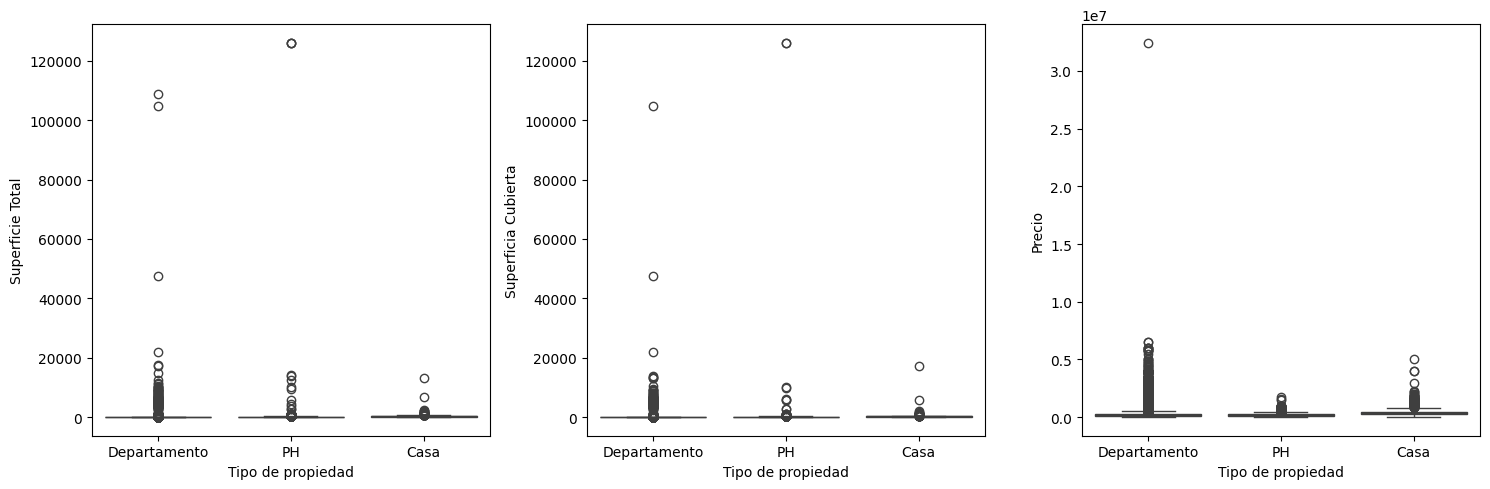

In [47]:
plt.rc('figure', figsize=(15, 5))
fig, axes = plt.subplots(ncols=3, nrows=1)

for i, ax in zip(range(3), axes.flat):
    lista=["surface_total","surface_covered","price"]
    lista2=["Superficie Total","Superficia Cubierta","Precio"]
    sns.boxplot(data = im2, x='property_type',y=lista[i],ax=ax)
    ax.set_ylabel(lista2[i])
    ax.set_xlabel('Tipo de propiedad')


plt.tight_layout()
plt.show()

Observando los anteriores boxplot se confirma que existen datos outliers que influyen en la información general del dataset.

Antes de realizar el análisis de outliers en el dataset, se procederá a filtrar los datos de superficie total que sean menores que superficie cubierta, esto debido a que son datos que carecen de lógica y es necesario identificarlos para que no afecten a la hora de visualizar la información y hacer una imputación o predicción con esta.

In [48]:
cmat=im2[(im2.surface_total<im2.surface_covered)]
cmat.shape,im2.shape

((760, 14), (89874, 14))

In [49]:
print('Esto quiere decir que el porcentaje del dataset donde la superficie total es menor que la superficie cubierta es de  %.2f%% '% por(cmat.shape[0],im2.shape[0]))

Esto quiere decir que el porcentaje del dataset donde la superficie total es menor que la superficie cubierta es de  0.85% 


Si bien es una gran cantidad de datos, el porcentaje que representa de la base de datos no es mucha, por lo tanto en lugar de agregarlos como valores faltantes al dataset, el cual ya tiene una cantidad significativa de valores faltantes para superficie total, se escoge filtrar estos valores.

In [50]:
im3=pd.concat([im2,cmat]).drop_duplicates(keep=False)
del cmat
im3.shape

(89114, 14)

### Outliers

Para este analisis se definiran las funciones para hallar los primeros estimativos de los limites superiores (inicialmente) de los datos.

In [51]:
#Rango intercuantil
def limitri(df,x):
    Q1 = np.nanquantile(df[x],0.25)
    Q3 = np.nanquantile(df[x],0.75)
    IQR = Q3 - Q1
    LS =Q3+1.5*IQR
    LI = Q1-1.5*IQR
    return LS , LI

#3 sigmas
def limit3sig(df,x):
    sig=df[x].std()
    med=df[x].mean()
    LS=med+sig*3
    LI=med-sig*3
    return LS , LI

Además se define una función para realizar un filtro de datos por propiedad para un mejor analisis de outliers.

In [52]:
def filtropropiedad(df,x):
    a=df['property_type'].str.fullmatch(x)
    b=df[a]
    return b

dep=filtropropiedad(im3,'Departamento')
ph= filtropropiedad(im3,'PH')
casa=filtropropiedad(im3,'Casa')

#### 1. Superficie cubierta

In [53]:
print('Limites superiores superficie cubierta:')
print(' ')
for i in range(3):
    lista=['Departamento','PH','Casa']
    lista2=[dep,ph,casa]
    print(lista[i],':')
    print('rango intercuartil:',limitri(lista2[i],'surface_covered')[0],'m^2')
    print('regla de las tres sigmas:', limit3sig(lista2[i],'surface_covered')[0],'m^2')
    print('-----')

Limites superiores superficie cubierta:
 
Departamento :
rango intercuartil: 155.5 m^2
regla de las tres sigmas: 1541.124224831284 m^2
-----
PH :
rango intercuartil: 213.0 m^2
regla de las tres sigmas: 5638.838326661699 m^2
-----
Casa :
rango intercuartil: 442.5 m^2
regla de las tres sigmas: 571.2671423806381 m^2
-----


Con la información anterior se puede concluir que la regla de las tres sigmas no es una forma óptima de encontrar los outliers de este dataset, esto debido a los valores que vimos nos imprime la base de datos como desviación estándar. Por esta razón, el análisis se realizará con el rango intercuartil como guía.

#### 1.1 Limite superior

Para realizar este análisis se tomara el valor dado por el rango intercuartil para cada tipo de propiedad como límite superior de los datos de cada propiedad y se realizará un histograma con los valores que se cuentan como outliers para este límite, de ahí se evaluará si el límite es adecuado.

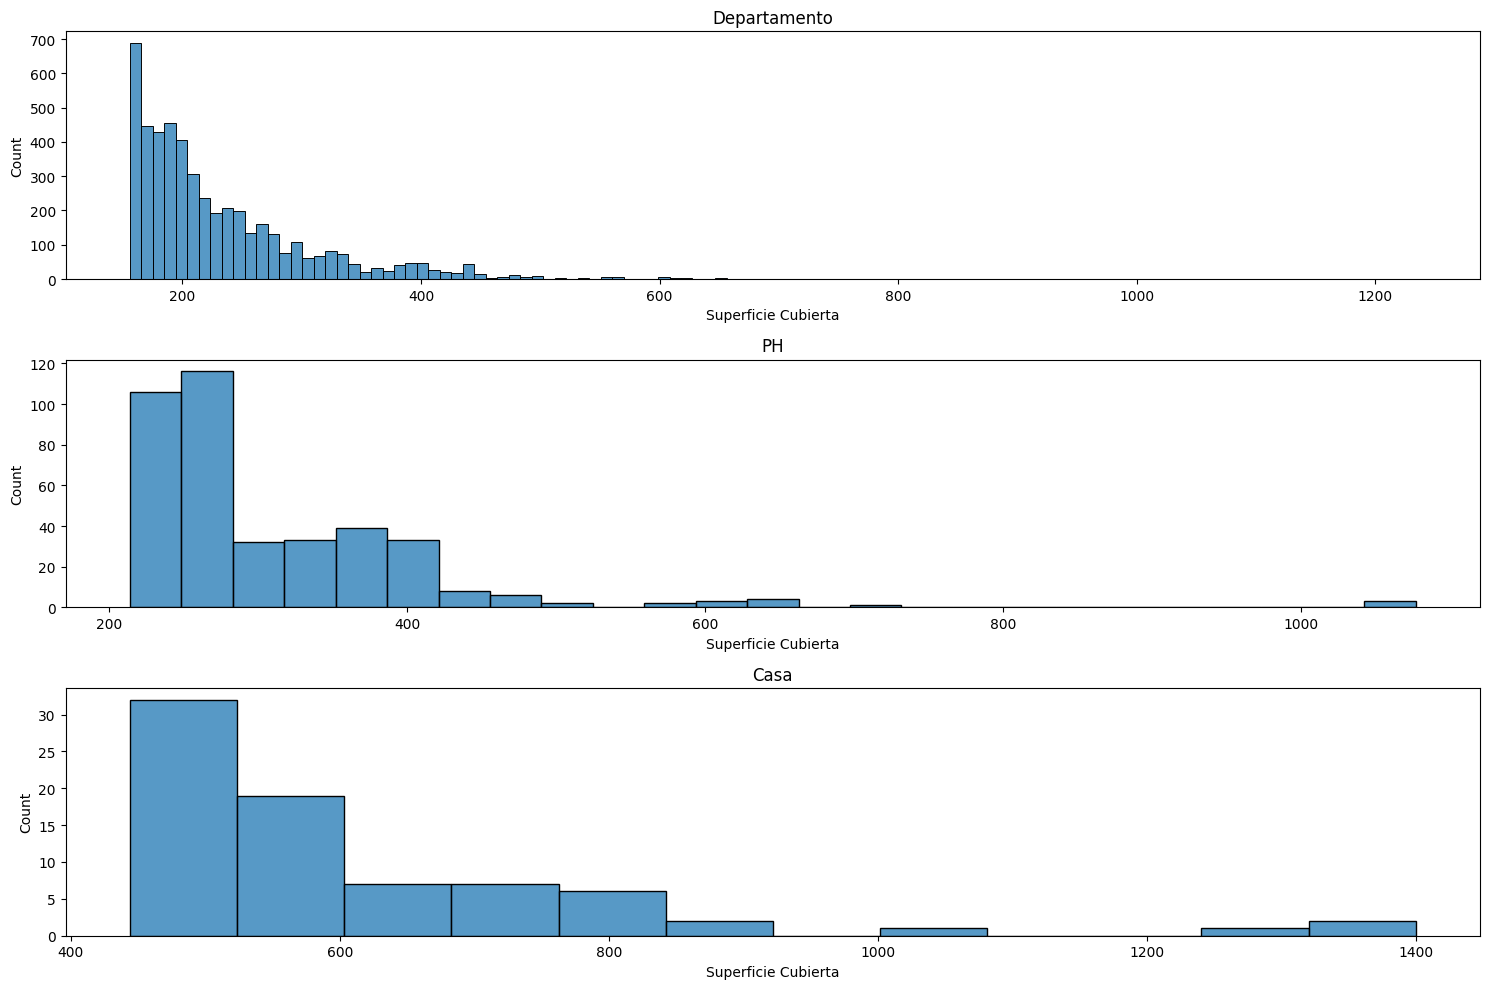

In [54]:
plt.rc('figure', figsize=(15, 10))
fig, axes = plt.subplots(ncols=1, nrows=3)

for i, ax in zip(range(3), axes.flat):
    lista=[dep,ph,casa]
    lista2=['Departamento','PH','Casa']
    sns.histplot(data = lista[i][np.logical_and(lista[i].surface_covered>(limitri(lista[i],'surface_covered')[0]),lista[i].surface_covered<2500)],x = "surface_covered",ax=ax)
    ax.set_title(lista2[i])
    ax.set_xlabel('Superficie Cubierta')

plt.tight_layout()
plt.show()

De las gráficas es posible ver que para departamento el límite que genera el rango intercuertil para esos datos deja por fuera una gran cantidad de datos, por lo tanto no es adecuado y es preferible un límite que se encuentre alrededor de los $500m^2$, igual en el caso de PH donde se puede tomar el límite en un valor alrededor de $400m^2$, en el caso de casa el rango intercuartil no da un mal limite, para este se tomara como límite $500m^2$

In [55]:
f1dep=dep[dep.surface_covered>500]

f2ph=ph[ph.surface_covered>400]

f3casa=casa[casa.surface_covered>500]


osc1=pd.concat([f1dep,f2ph])
oscs=pd.concat([osc1,f3casa])

im4=pd.concat([im3,oscs]).drop_duplicates(keep=False)

A continuación se visualiza un boxplot con los datos resultantes al eliminar outliers.

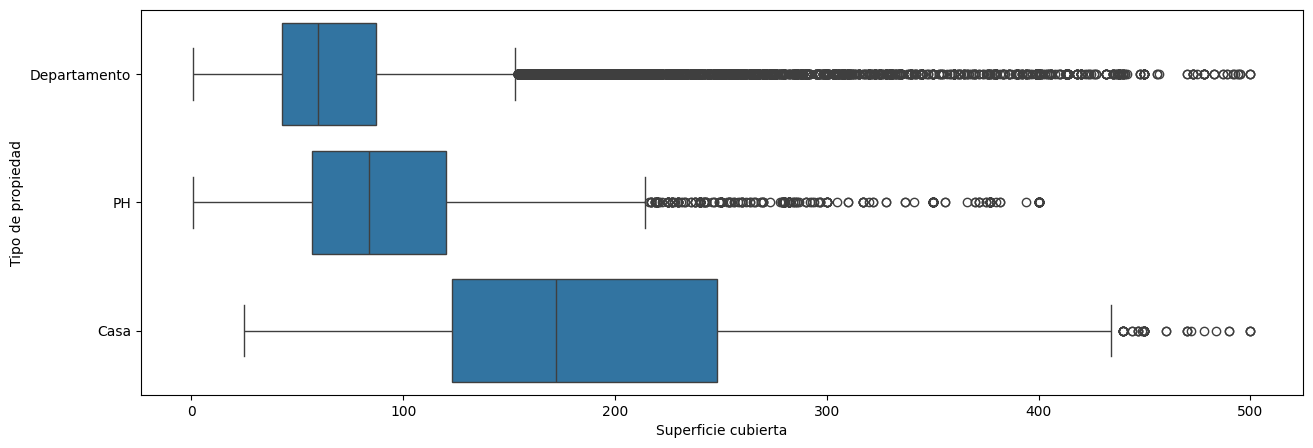

In [56]:
fig = plt.figure(figsize=(15, 5))
sns.boxplot(data=im4,y='property_type',x='surface_covered')
plt.xlabel('Superficie cubierta')
plt.ylabel('Tipo de propiedad')
plt.show()

En las dos graficas siguientes se tienen histogramas correspondiente a los datos por propiedad y outliers, respectivamente.

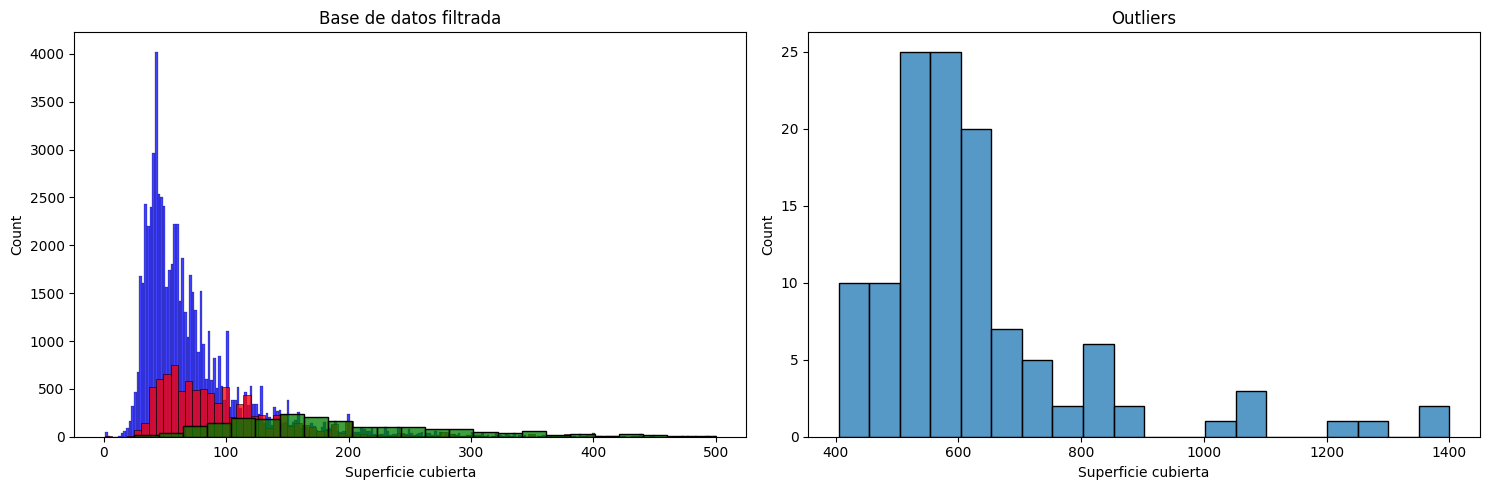

In [57]:
fig = plt.figure(figsize=(15, 5))

plt.subplot(121)
sns.histplot(data = pd.concat([dep,f1dep]).drop_duplicates(keep=False), x='surface_covered',color='b')
sns.histplot(data = pd.concat([ph,f2ph]).drop_duplicates(keep=False), x='surface_covered',color='r' )
sns.histplot(data = pd.concat([casa,f3casa]).drop_duplicates(keep=False), x='surface_covered',color='g' )
plt.xlabel('Superficie cubierta')
plt.title('Base de datos filtrada')

plt.subplot(122)
sns.histplot(data = oscs[oscs.surface_covered<2000],x = "surface_covered")
plt.xlabel('Superficie cubierta')
plt.title('Outliers')

plt.tight_layout()
plt.show()

In [58]:
print('El porcentaje de outliers superiores para superficie cubierta respecto a la base de datos es de %.2f%% '% por(im3.shape[0]-im4.shape[0],im3.shape[0]))

El porcentaje de outliers superiores para superficie cubierta respecto a la base de datos es de 0.22% 


#### 1.1 Limite inferior

Para hacer el analisis de valores atipicos inferiores del dataset, se tendra en cuenta que existen propiedades monoambientes, por lo tanto, se pondrá $20m^2$ como limite empirico inicial para el analisis de acuerdo a la documentacion encontrada de propiedades de este tipo.

In [59]:
osci=im4[im4.surface_covered<20]
osci.head()

,start_date,end_date,lat,lon,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,title,description,property_type
291,2019-03-04,2019-03-12,-34.619823,-58.437283,Caballito,1.0,1.0,NaN,14.0,14.0,27000.0,"EXCELENTE COCHERA, EXCELENTE INVERSION !",Corredor Responsable: Uno Bienes Raices SRL - ...,Departamento
757,2019-12-30,2020-01-24,-34.611445,-58.420994,Almagro,1.0,1.0,1.0,28.0,18.0,61000.0,MONOAMBIENTE AL FRENTE CON BALCÓN CORRIDO,Monoambiente con cocina integrada a gas. Peque...,Departamento
852,2019-07-08,2019-09-11,-34.560811,-58.463965,Belgrano,1.0,1.0,1.0,33.0,3.0,115000.0,Excelente monoambiente a estrenar al frente co...,Excelente monoambiente a estrenar al frente mu...,Departamento
1619,2019-09-21,2019-12-23,NaN,NaN,Palermo,3.0,2.0,1.0,NaN,1.0,236000.0,3 Ambientes a estrenar c/ cochera y parrilla e...,Moderno departamento de 3 ambientes a estrenar...,Departamento
1895,2019-09-21,2019-12-23,-34.591349,-58.393495,Recoleta,4.0,3.0,3.0,182.0,15.0,950000.0,Semipiso en venta en Torre con Amenities - Rec...,Excelente semipiso en Torre con Amenities ( SU...,Departamento


Al imprimir las instancias que corresponden a los outliers se pueden ver entradas como la primera que hay datos que están mal clasificados, puesto que la descripción del inmueble muestra que este es una cochera pero tiene la etiqueta de departamento en tipo de propiedad. Al hacer el filtro desde este valor aseguramos que no queden en la base de datos otras instancias que puedan pertenecer a tipos de propiedad que sean parqueaderos o cocheras. Sin embargo, esto da cuenta que hay posibilidad de hacer un análisis respecto a descripción y título de la base de datos, que nos ayude a identificar si está bien etiquetado el inmueble o quizá buscar otro tipo de información que ayude en cuanto a la imputación de datos atípicos o nulos.

Sin embargo, se puede hacer un pequeño análisis de los valores para superficie cubierta de menos de 20 metros cuadrados en función de observar si es posible "salvar" ciertos datos del filtro. Para esto, miremos primero qué instancias clasificadas con menos de 20 metros cuadrados aparecen que tienen más de una habitación y un baño.

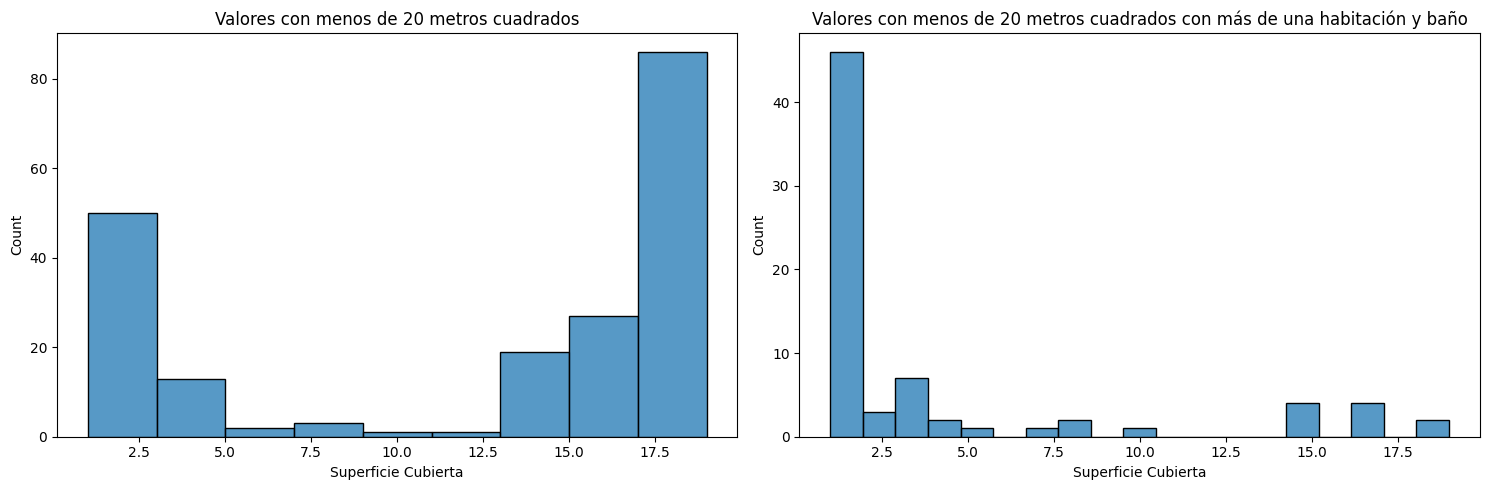

In [60]:
pf=np.logical_or(im4.rooms>1,im4.bathrooms>1)
dss=im4[np.logical_and(pf,im4.surface_covered<20)]

fig = plt.figure(figsize=(15, 5))

plt.subplot(121)
sns.histplot(data = osci,x = "surface_covered")
plt.title('Valores con menos de 20 metros cuadrados')
plt.xlabel('Superficie Cubierta')

plt.subplot(122)
sns.histplot(data = dss,x = "surface_covered")
plt.title('Valores con menos de 20 metros cuadrados con más de una habitación y baño')
plt.xlabel('Superficie Cubierta')

plt.tight_layout()
plt.show()

Claramente los valores que cumplen tal filtro estan mal clasificados, asi que es posible eliminarlos completamente.

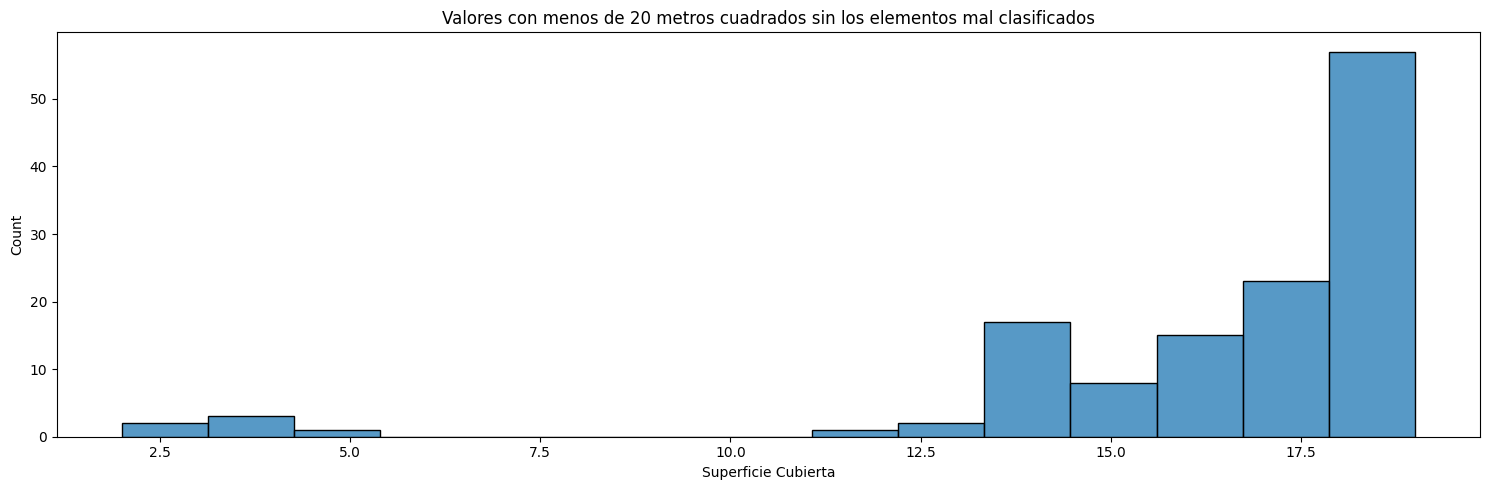

In [61]:
osci1=pd.concat([osci,dss]).drop_duplicates(keep=False)

fig = plt.figure(figsize=(15, 5))
sns.histplot(data = osci1,x = "surface_covered")
plt.title('Valores con menos de 20 metros cuadrados sin los elementos mal clasificados')
plt.xlabel('Superficie Cubierta')

plt.tight_layout()
plt.show()

In [62]:
osci1[osci1.surface_covered>15]

,start_date,end_date,lat,lon,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,title,description,property_type
757,2019-12-30,2020-01-24,-34.611445,-58.420994,Almagro,1.0,1.0,1.0,28.0,18.0,61000.0,MONOAMBIENTE AL FRENTE CON BALCÓN CORRIDO,Monoambiente con cocina integrada a gas. Peque...,Departamento
2021,2019-08-18,2019-09-14,-34.594753,-58.395816,Recoleta,1.0,1.0,1.0,17.0,17.0,72000.0,MONOAMBIENTE EN VENTA,Corredor Responsable: Fernando Muñoz - CUCICBA...,Departamento
4643,2019-04-27,2019-06-18,-34.546869,-58.478657,Saavedra,1.0,0.0,1.0,18.0,18.0,54000.0,DEPARTAMENTO EN VENTA,Xintel (NVS-NVS-293) Venta de Departamento MON...,Departamento
5368,2019-11-01,2019-12-23,-34.593222,-58.399191,Recoleta,1.0,1.0,1.0,19.0,19.0,53000.0,MONOAMBIENTE EN RECOLETA,"AMBIENTE Y MEDIO EN RECOLETA, CERCA A MEDIO DE...",Departamento
5408,2019-11-01,2019-11-06,-34.580714,-58.495685,Villa Pueyrredón,1.0,1.0,1.0,19.0,19.0,49000.0,MICRODEPARTAMENTO A ESTRENAR OPORTUNIDAD!!!,Corredor Responsable: Jose Guendler - C.U.C.I....,Departamento
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81675,2019-09-14,2019-09-17,-34.599104,-58.429181,Villa Crespo,1.0,1.0,1.0,17.0,17.0,55000.0,VENTA - VILLA CRESPO - MONOAMBIENTE,Departamento Monoambiente Para Mudarte Ya! Mon...,Departamento
82894,2019-07-31,2019-08-14,-34.660079,-58.503122,Mataderos,1.0,1.0,1.0,25.0,17.0,57000.0,VENTA DEPARTAMENTO MONOAMBIENTE LUMINOSO,Espectacular departamento monoambiente luminos...,Departamento
82895,2019-07-31,2019-09-21,-34.625870,-58.384003,Constitución,1.0,1.0,1.0,17.0,17.0,32000.0,EN VENTA MONOAMBIENTE EN C.A.B.A.,EN VENTA MONOAMBIENTE EN C.A.B.A.departamento ...,Departamento
82899,2019-07-31,2019-08-13,-34.626413,-58.422842,Boedo,1.0,1.0,1.0,19.0,19.0,60000.0,BOEDO - VENTA MONOAMBIENTE - AV SAN JUAN 4100,Venta monoambiente en el barrio de Boedo. Exce...,Departamento


Esto quiere decir que aun hay ciertos valores que se pueden agregar al data set, de esta forma se realiza un filtro de los valores de más de 15 metros cuadrados de estos outliers y se le agregaran al data set.

In [63]:
im5=pd.concat([im4,dss]).drop_duplicates(keep=False)
im5=pd.concat([im5,im5[im5.surface_covered<15]]).drop_duplicates(keep=False)
im5.shape,im4.shape

((88819, 14), (88918, 14))

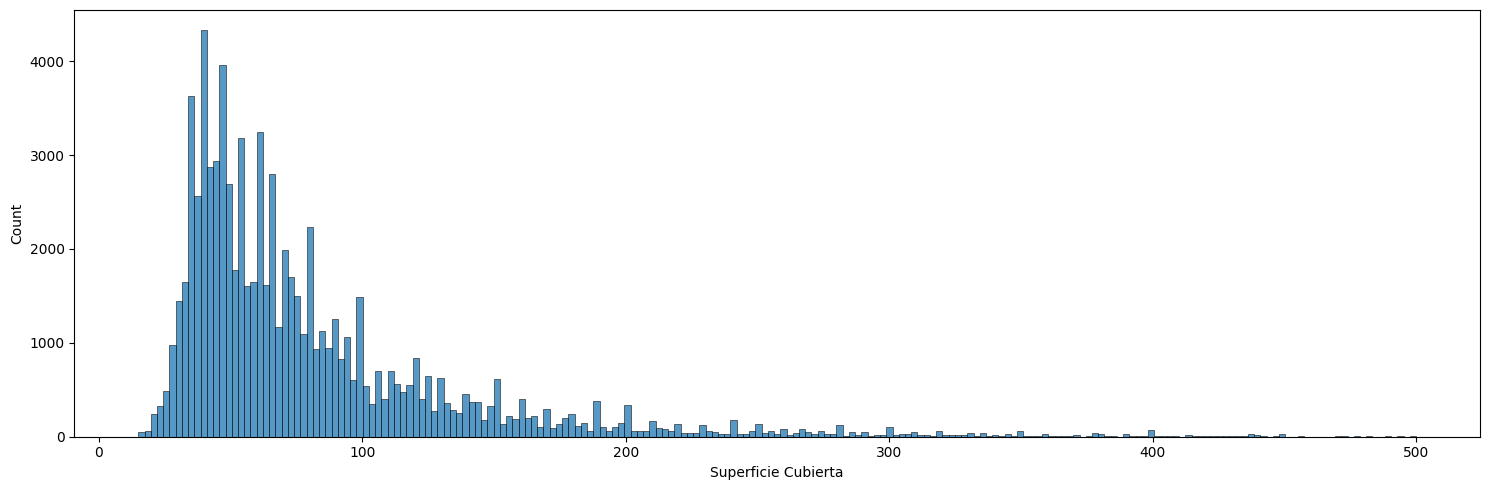

In [64]:
fig = plt.figure(figsize=(15, 5))
sns.histplot(data = im5,x = "surface_covered")
plt.xlabel('Superficie Cubierta')

plt.tight_layout()
plt.show()

In [65]:
print('El porcentaje de outliers inferiores para superficie cubierta respecto a la base de datos es de %.2f%% '% por(im4.shape[0]-im5.shape[0],im4.shape[0]))
print('El porcentaje de outliers totales para superficie cubierta respecto a la base de datos original es de %.2f%% '% por(im3.shape[0]-im5.shape[0],im3.shape[0]))

El porcentaje de outliers inferiores para superficie cubierta respecto a la base de datos es de 0.11% 
El porcentaje de outliers totales para superficie cubierta respecto a la base de datos original es de 0.33% 


#### 2. Superficie total

In [66]:
print('Limite superior superficie total rango intercuartil',limitri(im5,'surface_total')[0])

Limite superior superficie total rango intercuartil 201.5


A continuación se visualizará los outliers de superficie total según el rango intercuartil

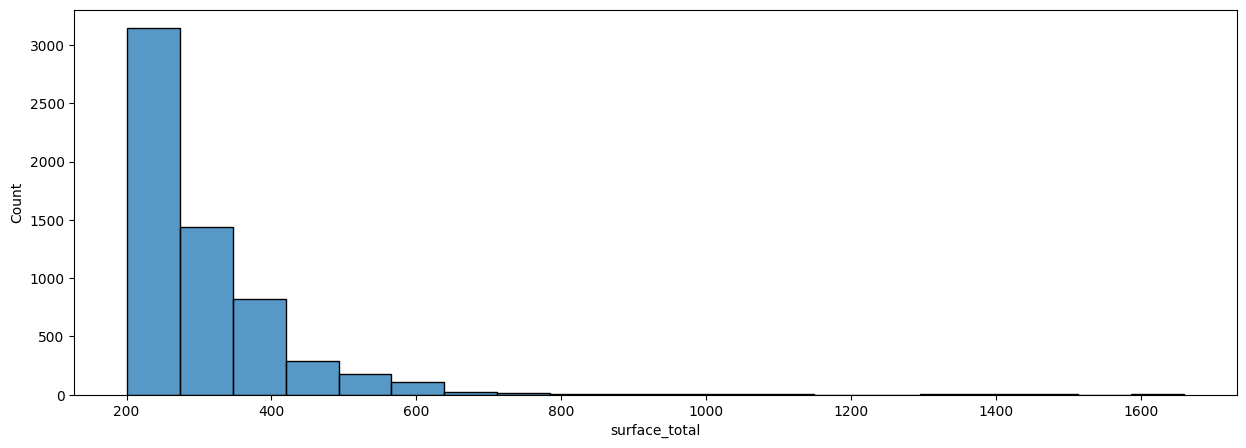

In [67]:
fig = plt.figure(figsize=(15, 5))

sns.histplot(data=im5[np.logical_and(im5.surface_total>200,im5.surface_total<2000)],x='surface_total',bins=20)

plt.show()

Es posible darse cuenta que muchos datos quedan fuera de la base de datos si se toma este limite, por lo tanto se toma como nuevo limite adecuado el valor de 800 metros cuadrados.

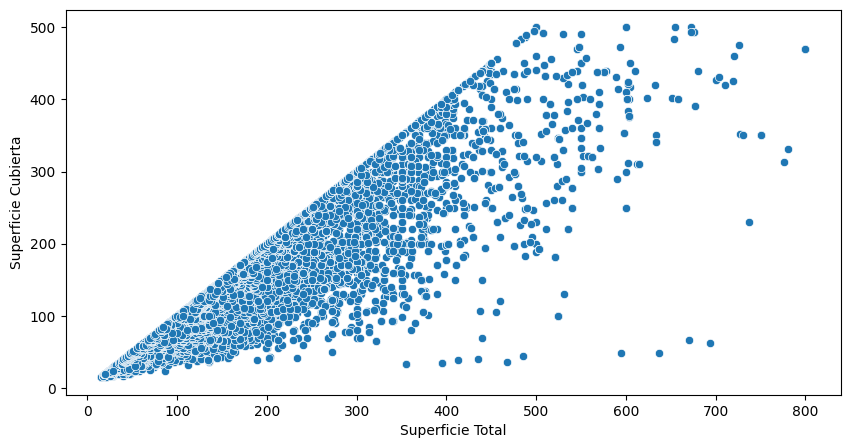

In [68]:
a22=im5[im5.surface_total>800]
im6=pd.concat([im5,a22]).drop_duplicates(keep=False)

fig = plt.figure(figsize=(10, 5))
sns.scatterplot(data = im6,x = "surface_total",y='surface_covered')
plt.xlabel('Superficie Total')
plt.ylabel('Superficie Cubierta')
plt.show()

La anterior grafica puede parecer extraña pero tiene sentido puesto que anteriormente se eliminaron todos aquellos datos de superficie total que fueran mayores que su respectiva superficie cubierta, por eso la base de datos pareciera tiene un corte abrupto a partir de la pendiente igual a 1.

In [69]:
print('El porcentaje de outliers para superficie total respecto a la base de datos es de %.2f%% '% por(im5.shape[0]-im6.shape[0],im5.shape[0]))

El porcentaje de outliers para superficie total respecto a la base de datos es de 0.07% 


#### 3. Precio

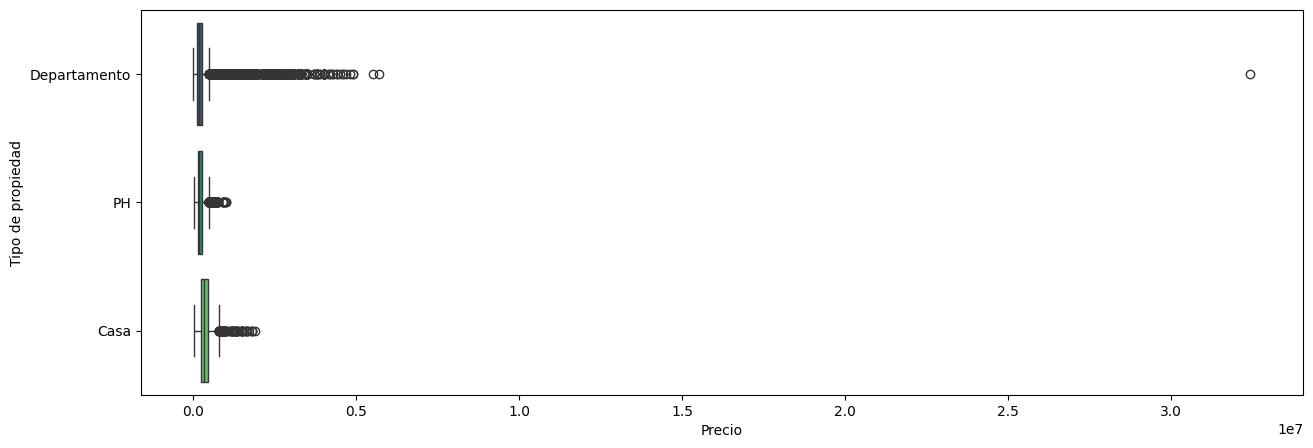

In [70]:
fig = plt.figure(figsize=(15, 5))
sns.boxplot(data = im6,y = 'property_type',x = "price",palette="viridis",hue='property_type', legend=False)
plt.xlabel('Precio')
plt.ylabel('Tipo de propiedad')
plt.show()

In [71]:
dep=filtropropiedad(im6,'Departamento')
ph= filtropropiedad(im6,'PH')
casa=filtropropiedad(im6,'Casa')

print('Limites superiores precio:')
print(' ')

for i in range(3):
    lista=['Departamento','PH','Casa']
    lista2=[dep,ph,casa]
    print(lista[i],':')
    print('rango intercuartil:',limitri(lista2[i],'price')[0],'dolares')
    print('-----')

Limites superiores precio:
 
Departamento :
rango intercuartil: 495213.75 dolares
-----
PH :
rango intercuartil: 472500.0 dolares
-----
Casa :
rango intercuartil: 789500.0 dolares
-----


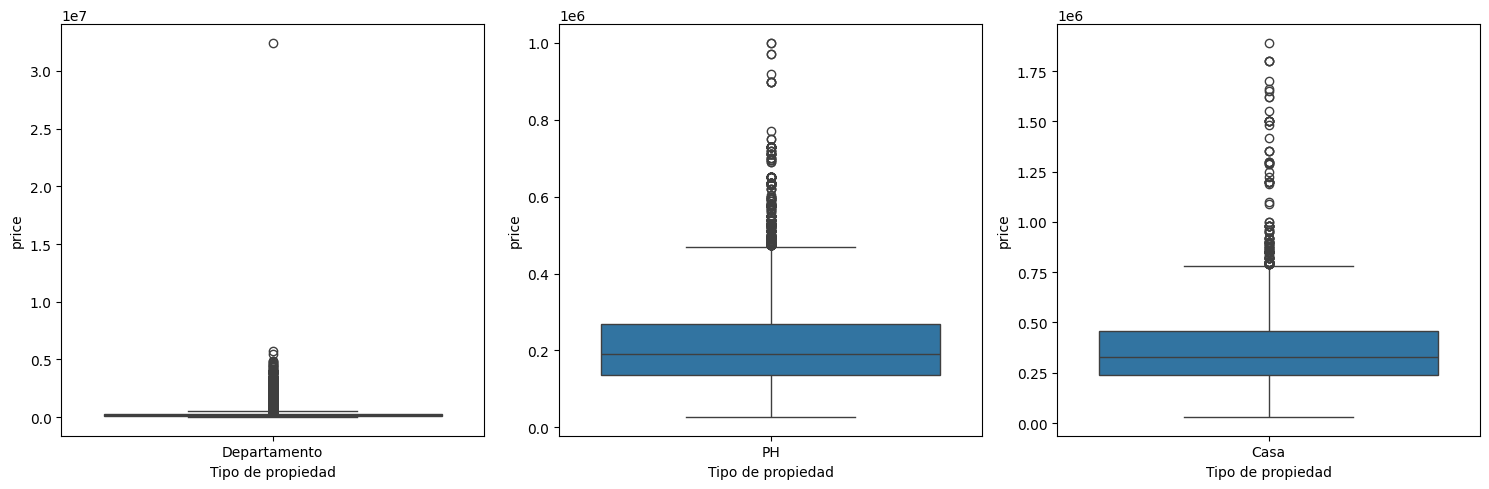

In [72]:
plt.rc('figure', figsize=(15, 5))
fig, axes = plt.subplots(ncols=3, nrows=1)

for i, ax in zip(range(3), axes.flat):
    lista=[dep,ph,casa]
    lista2=['Departamento','PH','Casa']
    sns.boxplot(data = lista[i], y='price',x='property_type' ,ax=ax)
    ax.set_xlabel('Tipo de propiedad')


plt.tight_layout()
plt.show()

De los boxplot por tipo de propiedad se ve que los valores para PH y Casa tienen ciertos valores que se pueden filtrar como outliers aunque no generan una gran influencia en el data set al no ser tan drasticos en su valor como en departamento donde hay un valor atipico que no permite la buena visualización de la distribución.

Se graficaran ahora los outliers dados por el rango intercuartil.

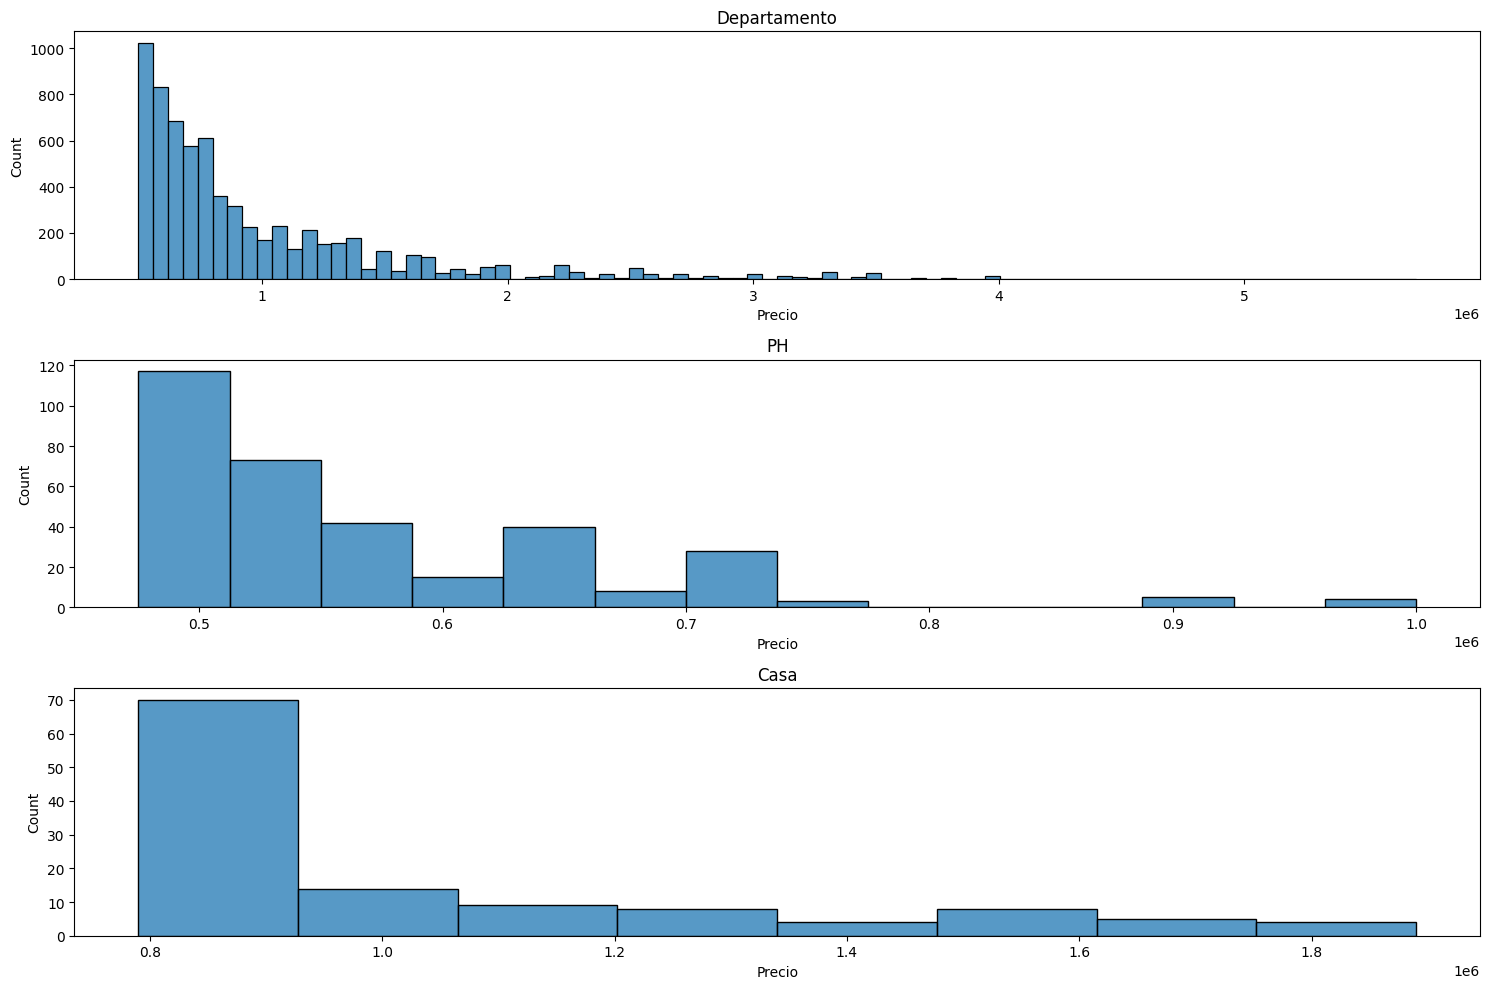

In [73]:
plt.rc('figure', figsize=(15, 10))
fig, axes = plt.subplots(ncols=1, nrows=3)

for i, ax in zip(range(3), axes.flat):
    lista=[dep,ph,casa]
    lista2=['Departamento','PH','Casa']
    sns.histplot(data = lista[i][np.logical_and(lista[i].price>limitri(lista[i],'price')[0],lista[i].price<1e7)],x = "price",ax=ax)
    ax.set_title(lista2[i])
    ax.set_xlabel('Precio')

plt.tight_layout()
plt.show()

El filtro por rango intercuartil deja datos por fuera que no parecen ser outliers y son utiles, por lo tanto se toma un nuevo limite como filtro, para departamento el limite superior será de 2e6 dolares, para PH 8e5 dolares y para casa 1e6 dolares.

In [74]:
f1depp=dep[dep.price>2e6]
f2php=ph[ph.price>8e5]
f3casap= casa[casa.price>1e6]

op=pd.concat([f1depp,f2php])
op1=pd.concat([op,f3casap])

im7=pd.concat([im6,op1]).drop_duplicates(keep=False)

print('El porcentaje de outliers para precio respecto a la base de datos es de %.2f%% '%por(im6.shape[0]-im7.shape[0],im6.shape[0]))

El porcentaje de outliers para precio respecto a la base de datos es de 0.53% 


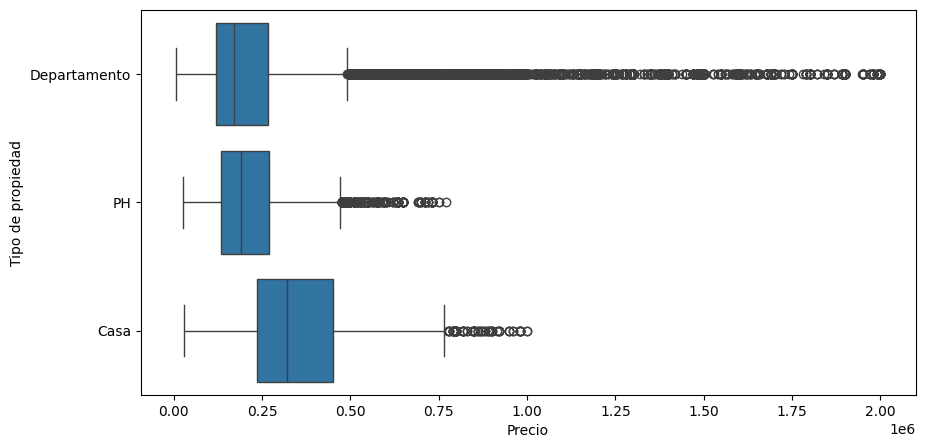

In [75]:
fig = plt.figure(figsize=(10, 5))
sns.boxplot(data = im7, x='price',y='property_type')
plt.ylabel('Tipo de propiedad')
plt.xlabel('Precio')
plt.show()

Una vez realizado el filtro de los valores atipicos en los datos que mostraban valores que no tenian mucho sentido de desviación estandar, se realiza un describe para asegurarse de que estos ahora tengan valores más acordes, ademas se realiza un pairplot con la intencion de revisar si las demas variables también cuentan con valores atipicos.

In [76]:
im7.describe()

,lat,lon,rooms,bedrooms,bathrooms,surface_total,surface_covered,price
count,83968.000000,83954.000000,88283.000000,88283.000000,86157.000000,79630.000000,79279.000000,8.828300e+04
mean,-34.599084,-58.436118,2.944021,1.944927,1.541732,92.793432,79.939593,2.439093e+05
std,0.023975,0.036226,1.279036,1.052421,0.825529,70.137653,55.231772,2.239490e+05
min,-34.696419,-58.530468,1.000000,0.000000,1.000000,15.000000,15.000000,6.000000e+03
25%,-34.613858,-58.459755,2.000000,1.000000,1.000000,49.000000,44.000000,1.200000e+05
50%,-34.599409,-58.433810,3.000000,2.000000,1.000000,70.000000,63.000000,1.750000e+05
75%,-34.584227,-58.410315,4.000000,3.000000,2.000000,110.000000,95.000000,2.750000e+05
max,-34.535818,-58.353930,21.000000,15.000000,14.000000,800.000000,500.000000,2.000000e+06


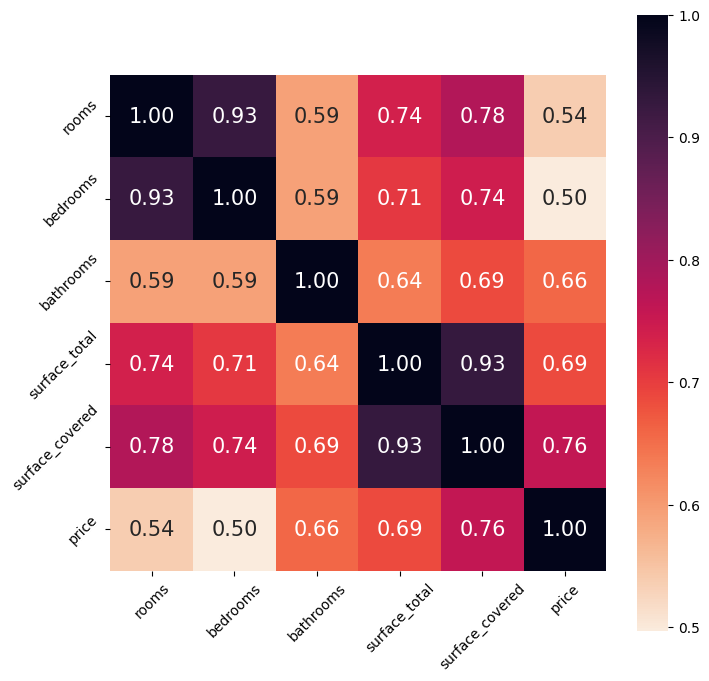

In [77]:
fc=im7.drop(columns=['start_date','end_date','lat','lon','l3','title','description'],inplace=False)

corr = fc.drop(columns = 'property_type').corr()
plt.figure(figsize=(8,8))
sns.heatmap(corr, cbar = True,  square = True, annot=True, fmt= '.2f',annot_kws={'size': 15},
           xticklabels= fc.drop(columns = 'property_type').columns,
           yticklabels= fc.drop(columns = 'property_type').columns,
           cmap= "rocket_r")
plt.xticks(rotation = 45)
plt.yticks(rotation = 45)
plt.show()

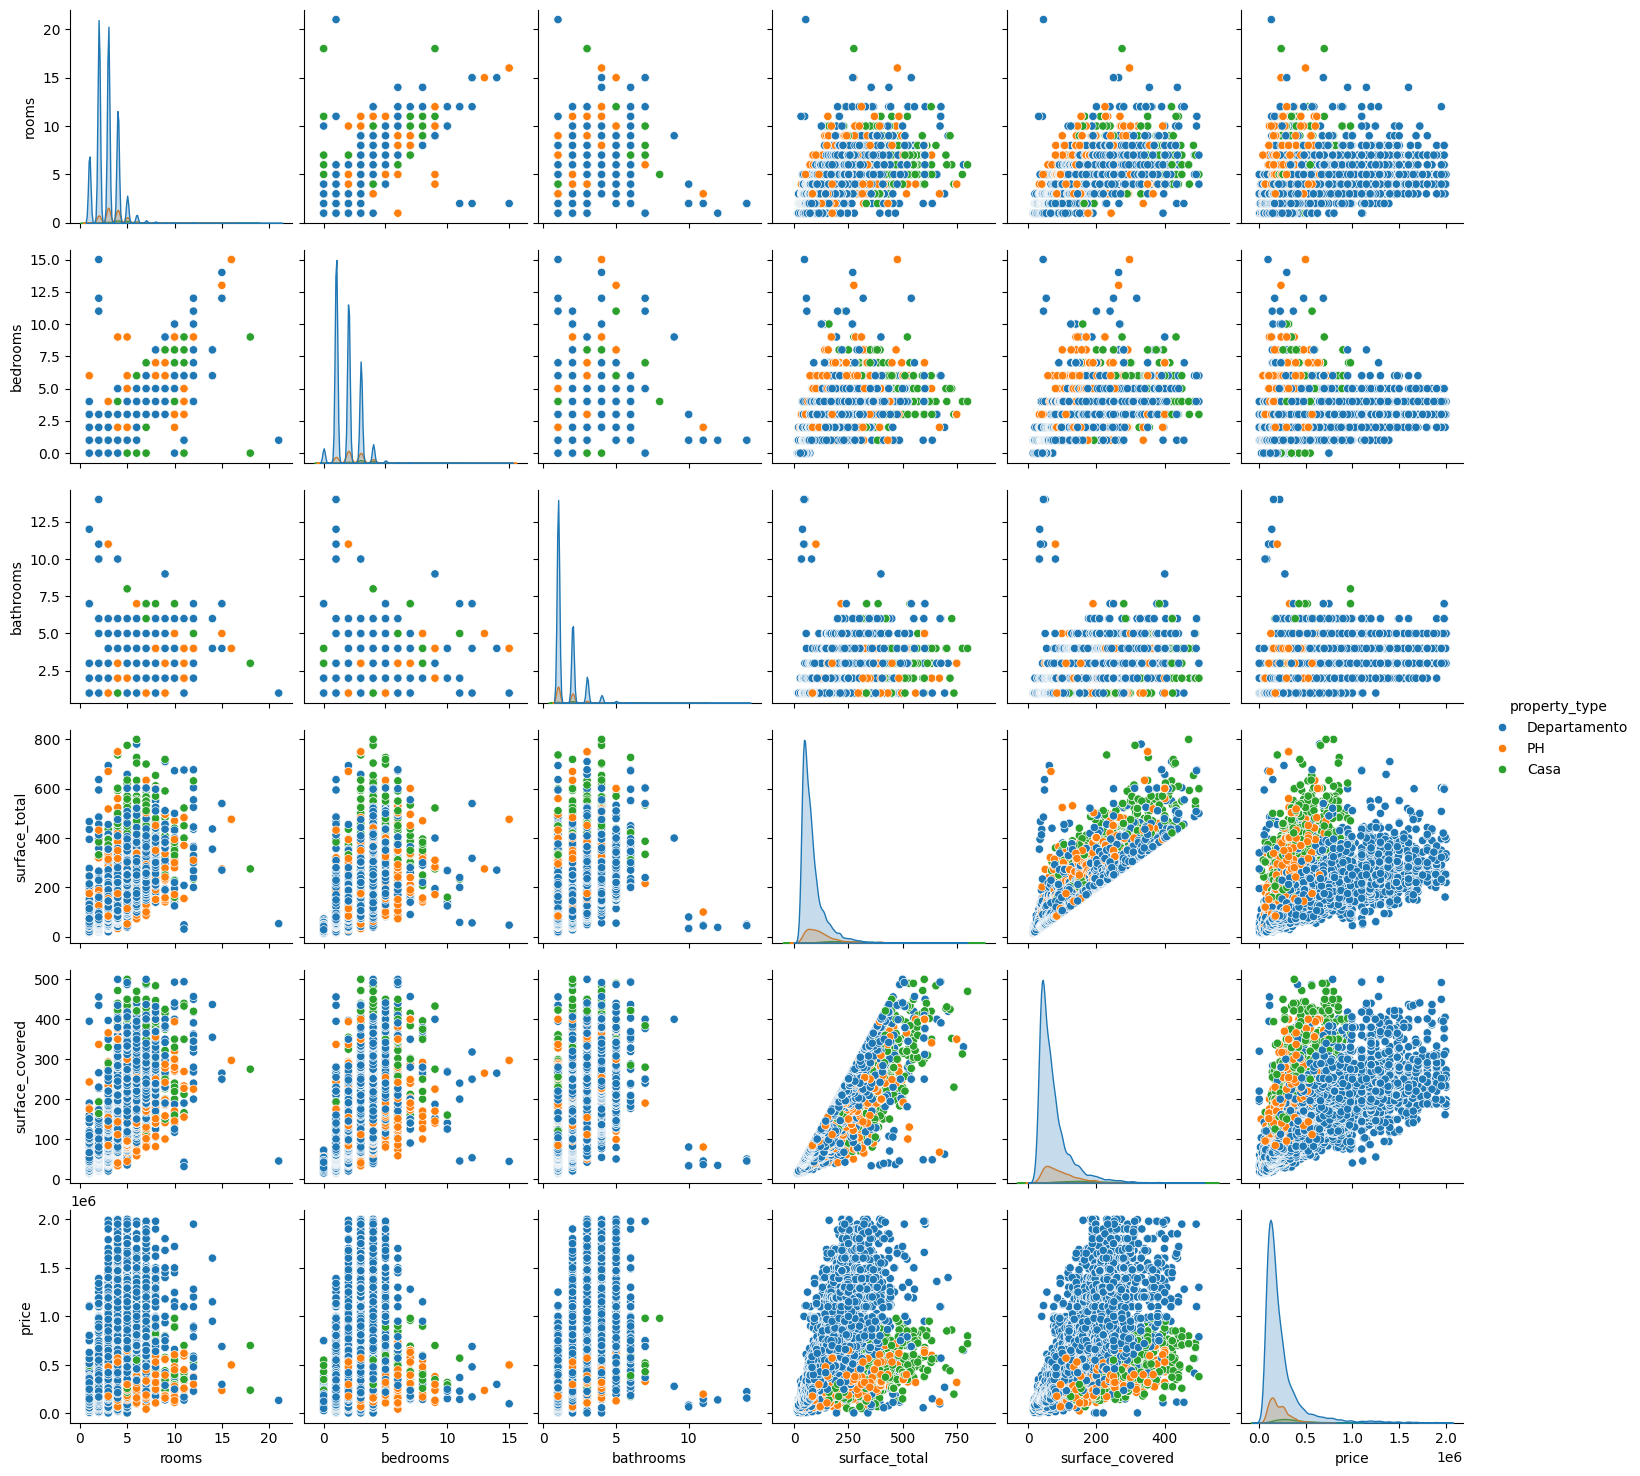

In [79]:
sns.pairplot(fc, hue = 'property_type')
plt.show()

Del pairplot se puede concluir que los datos de superficie total, cubierta y precio parecen tener valores acordes, sin embargo, a la hora de ver los atributos de baños, habitaciones y dormitorios, hay entradas con valores muy grandes los cuales parecieran no tener mucho sentido y estan lejanos de la mayoria de datos, por lo tanto se realizara un filtro de estos datos, si son pocos se agregaran como valores nulos.

#### 4. Baños, habitaciones, dormitorios

Se grafica la cantidad de datos por cantidad.

In [ ]:
plt.rc('figure', figsize=(18, 5))
fig, axes = plt.subplots(ncols=3, nrows=1)

for i, ax in zip(range(3), axes.flat):
    lista=['rooms','bedrooms','bathrooms']
    lista2=['Habitaciones','Dormitorios','Baños']
    sns.countplot(data = im7[im7[lista[i]]>limitri(im7,lista[i])[0]], x=lista[i] ,ax=ax)
    ax.set_xlabel(lista2[i])

plt.tight_layout()
plt.show()

Se realiza el filtro de acuerdo a lo que se visualiza y se grafican los resultados.

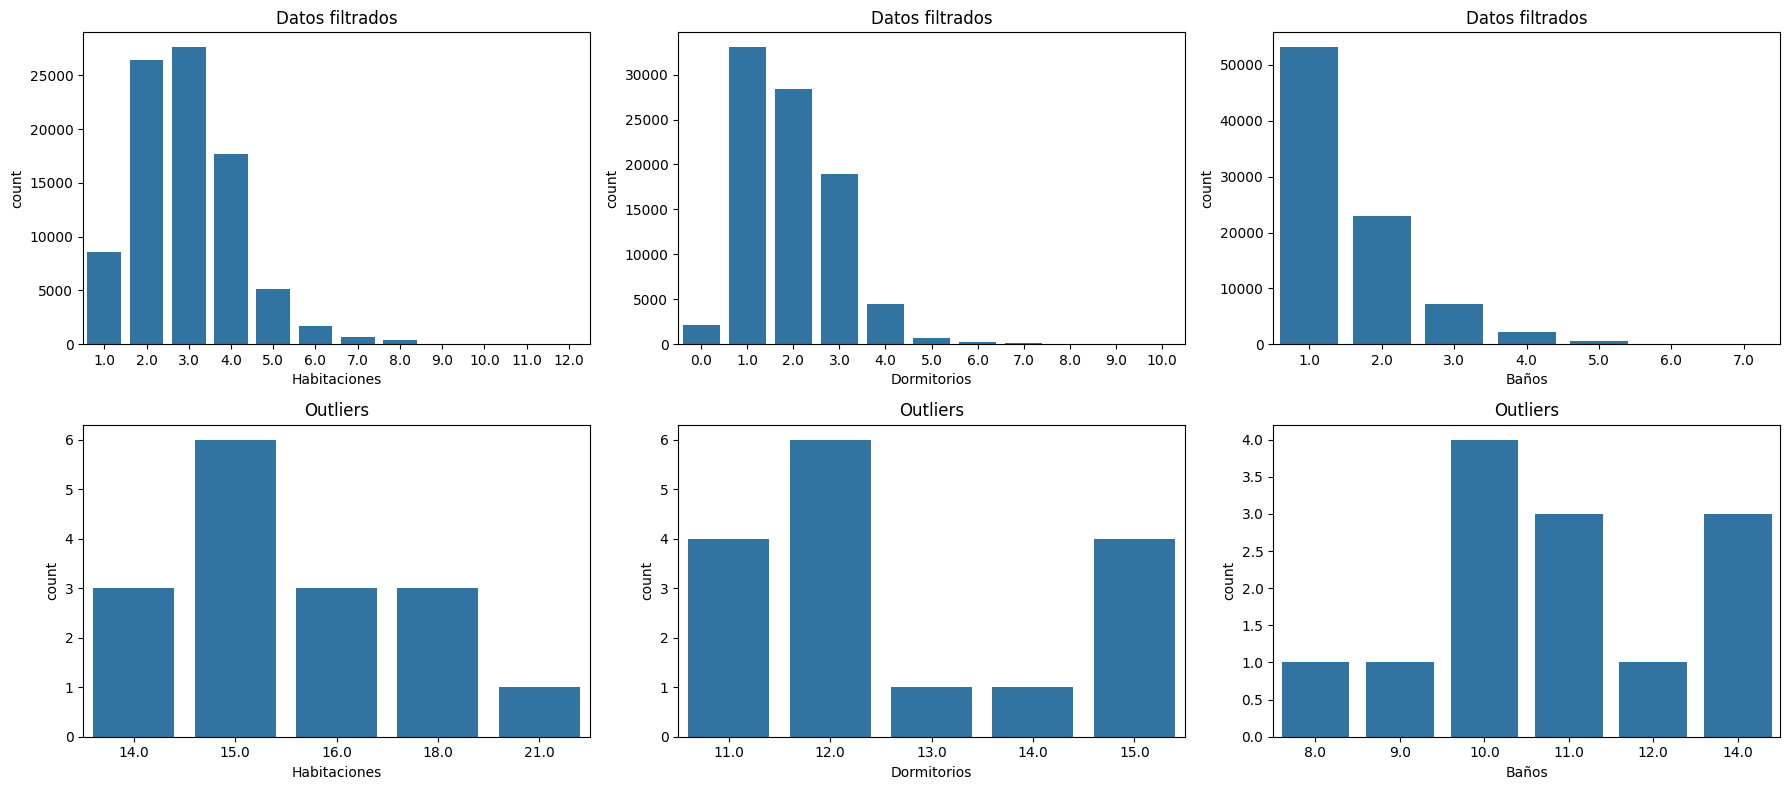

In [80]:
plt.rc('figure', figsize=(18, 8))
fig, axes = plt.subplots(ncols=3, nrows=2)

for i, ax in zip(range(6), axes.flat):
    lista=['rooms','bedrooms','bathrooms','rooms','bedrooms','bathrooms']
    lista2=['Habitaciones','Dormitorios','Baños','Habitaciones','Dormitorios','Baños']
    lista3=[12,10,7,12,10,7]
    if i<3:
        sns.countplot(data = im7[im7[lista[i]]<=lista3[i]], x=lista[i] ,ax=ax)
        ax.set_xlabel(lista2[i])
        ax.set_title('Datos filtrados')
    else:
        sns.countplot(data = im7[im7[lista[i]]>lista3[i]], x=lista[i] ,ax=ax)
        ax.set_title('Outliers')
        ax.set_xlabel(lista2[i])

plt.tight_layout()
plt.show()

In [81]:
bf=np.logical_or(im7.rooms>12,im7.bedrooms>10)
ohdb=im7[np.logical_or(bf,im7.bathrooms>7)]
del bf
im8=pd.concat([im7,ohdb]).drop_duplicates(keep=False)
print('El porcentaje de outliers para habitaciones, dormitorios y baños respecto a la base de datos es de %.2f%% '%por(im7.shape[0]-im8.shape[0],im7.shape[0]))

El porcentaje de outliers para habitaciones, dormitorios y baños respecto a la base de datos es de 0.04% 


In [82]:
print('El porcentaje de outliers total %.2f%% '%por(im2.shape[0]-im8.shape[0],im8.shape[0]))

El porcentaje de outliers total 1.84% 


### Imputación valores faltantes

Recordemos la cantidad de valores faltantes que tenemos por atributo y su porcentaje respecto a la cantidad de datos del dataset.

In [83]:
vfaltante2=im8.isna().sum()
vfaltante2

,0
start_date,0
end_date,0
lat,4312
lon,4326
l3,0
rooms,0
bedrooms,0
bathrooms,2126
surface_total,8650
surface_covered,9001


In [84]:
im8.describe()

,lat,lon,rooms,bedrooms,bathrooms,surface_total,surface_covered,price
count,83935.000000,83921.000000,88247.000000,88247.00000,86121.000000,79597.000000,79246.000000,8.824700e+04
mean,-34.599081,-58.436128,2.941278,1.94274,1.539613,92.735053,79.898405,2.438434e+05
std,0.023974,0.036222,1.265315,1.04130,0.815300,69.988687,55.143158,2.238607e+05
min,-34.696419,-58.530468,1.000000,0.00000,1.000000,15.000000,15.000000,6.000000e+03
25%,-34.613850,-58.459759,2.000000,1.00000,1.000000,49.000000,44.000000,1.200000e+05
50%,-34.599400,-58.433823,3.000000,2.00000,1.000000,70.000000,63.000000,1.750000e+05
75%,-34.584224,-58.410374,4.000000,3.00000,2.000000,110.000000,95.000000,2.750000e+05
max,-34.535818,-58.353930,12.000000,10.00000,7.000000,800.000000,500.000000,2.000000e+06


In [85]:
print("Porcentaje de valores faltantes respecto al total de datos del data set")
for i in range(5):
    lista=['latitud','longitud','baños','superficie total','superficie cubierta']
    lista2=['lat','lon','bathrooms','surface_total','surface_covered']
    print(lista[i],': %.2f%% '% (por(vfaltante2[lista2[i]].sum(),im8.shape[0])))

Porcentaje de valores faltantes respecto al total de datos del data set
latitud : 4.89% 
longitud : 4.90% 
baños : 2.41% 
superficie total : 9.80% 
superficie cubierta : 10.20% 


Y veamos la correlación de cada variable respecto a la otra

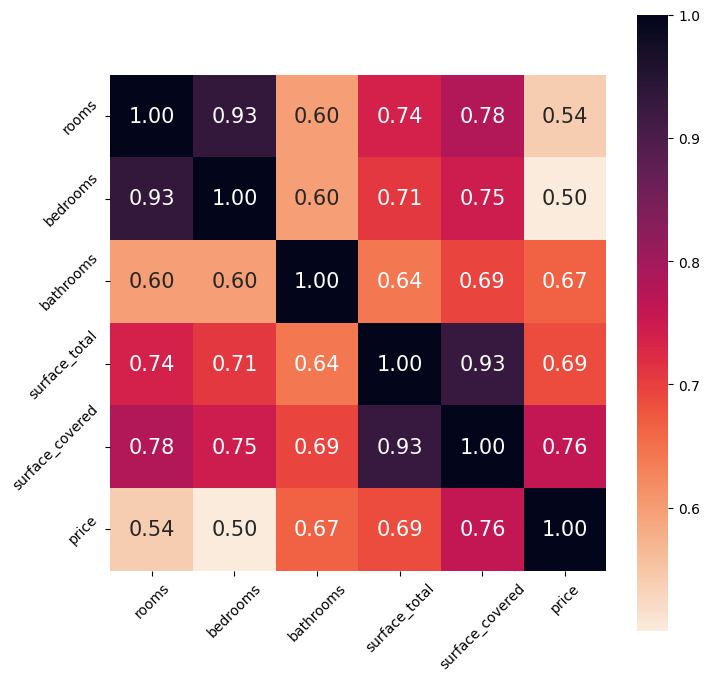

In [86]:
fc=im8.drop(columns=['start_date','end_date','lat','lon','l3','title','description'],inplace=False)

corr = fc.drop(columns = 'property_type').corr()
plt.figure(figsize=(8,8))
sns.heatmap(corr, cbar = True,  square = True, annot=True, fmt= '.2f',annot_kws={'size': 15},
           xticklabels= fc.drop(columns = 'property_type').columns,
           yticklabels= fc.drop(columns = 'property_type').columns,
           cmap= "rocket_r")
plt.xticks(rotation = 45)
plt.yticks(rotation = 45)
plt.show()

Como el objetivo del proyecto es crear un modelo que ayude a predecir el precio de los inmuebles y la variable con mayor correlación es superficie cubierta, nos centraremos en la imputación de esta variable inicialmente. Superficie total también cuenta con gran correlación respecto a precio pero como está a su tiempo tiene tanta correlación con superficie cubierta, se decide priorizar la imputación de superficie cubierta y omitir a superficie total para la creación del modelo. También es necesario la imputación de los baños esto debido a que es otra variable que cuenta con una buena correlación respecto a precio y que si bien su relación con superficie cubierta es grande, no lo es tanto.

Para la imputación de superficie cubierta se usará su relación respecto al precio, esto debido a que precio es una variable sin valores nulos y que el valor del metro cuadrado depende del sector.

Se observa inicialmente el comportamiento de precio vs superficie cubierta para algunos barrios en especifico con la intencion de conocer cómo se comporta esta relación.

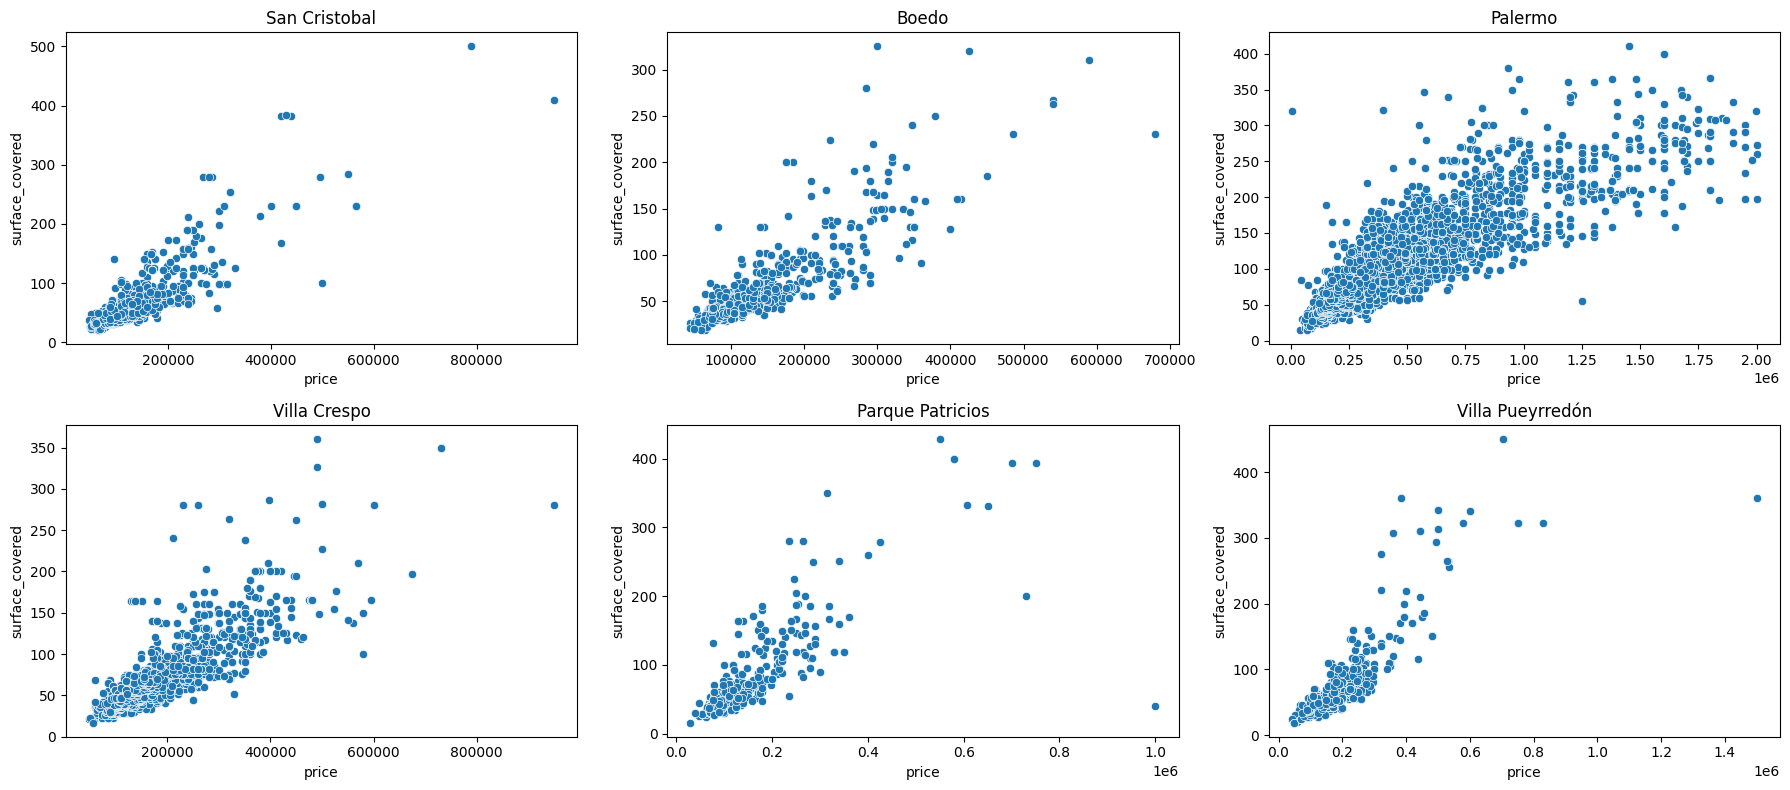

In [87]:
barrios=im8['l3'].unique()

plt.rc('figure', figsize=(18, 8))
fig, axes = plt.subplots(ncols=3, nrows=2)

for i, ax in zip(range(6), axes.flat):
    if i<3:
        sns.scatterplot(data = im8[im8.l3==barrios[i]], x='price',y='surface_covered' ,ax=ax)
        ax.set_title(barrios[i])
    else:
        sns.scatterplot(data = im8[im8.l3==barrios[i]], x='price',y='surface_covered' ,ax=ax)
        ax.set_title(barrios[i])

plt.tight_layout()
plt.show()


De las anteriores graficas se puede identificar vagamente que los datos se pueden ajustar con una relación lineal con cierta dispersión, por lo tanto, para la imputación se realizara un modelos de regresion lineal por barrio y se imputara cada valor con la regresion lineal de superficie cubierta y precio correspondiente a la de su barrio.

Se inicia con la regresión lineal de precio y superficie cubierta por barrio.

In [88]:
from sklearn.linear_model import LinearRegression

coeficientes=[]
interceptos=[]

#Regresión lineal por barrios
for i in barrios:
    a=im8['l3'].str.fullmatch(i)
    b=im8[a]
    b=b.dropna(subset=['surface_covered'])

    X=b[['price']]
    y=b[['surface_covered']]

    linear_model = LinearRegression()
    linear_model.fit(X,y)

    coef=linear_model.coef_
    interc=linear_model.intercept_

    coeficientes.append(coef[0][0])
    interceptos.append(interc[0])


Se crea una base de datos que contiene los valores de los coeficientes e interceptos para cada barrio.

In [89]:
incoba={'barrios':barrios,'coeficientes': coeficientes, 'interceptos': interceptos}
incoba=pd.DataFrame(incoba)
incoba.head()

,barrios,coeficientes,interceptos
0,San Cristobal,0.000512,-1.851608
1,Boedo,0.000462,-0.795205
2,Palermo,0.000166,27.813760
3,Villa Crespo,0.000395,-1.039661
4,Parque Patricios,0.000460,11.581321


Con esta información, es posible crear una función que identifique el barrio y el precio de cada instancia e imprima el valor de superficie cubierta correspondiente al de la regresión lineal.

In [90]:
import math

def imp(xbarrio,xprecio):
    for i in barrios:
        if xbarrio==i:
            a=incoba['barrios'].str.fullmatch(i)
            b=incoba[a]
            c=b['coeficientes']*xprecio+b['interceptos']
    return c

Con esta función se hallan valores aproximados que se ajusten al crecimiento del valor de precio debido a el aumento de la superficie cubierta y se imputan los valores faltantes con estas aproximaciones.

In [91]:
surfc=[]
barriosss=np.array(im8['l3'])
priceee=np.array(im8['price'])

for i in range(im8.shape[0]):
    a=imp(barriosss[i],priceee[i])
    surfc.append(a.values[0])

im8['surface_covered2']=surfc
im8['surface_covered'].fillna(im8['surface_covered2'], inplace=True)
del im8['surface_covered2']

/tmp/ipython-input-903821087.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  im8['surface_covered'].fillna(im8['surface_covered2'], inplace=True)


Una vez realizada la imputación se verifica la cantidad de valores faltantes y se hace un describe para identificar los cambios que genero la imputación.

In [92]:
im8.isna().sum()

,0
start_date,0
end_date,0
lat,4312
lon,4326
l3,0
rooms,0
bedrooms,0
bathrooms,2126
surface_total,8650
surface_covered,0


In [93]:
im8.describe()

,lat,lon,rooms,bedrooms,bathrooms,surface_total,surface_covered,price
count,83935.000000,83921.000000,88247.000000,88247.00000,86121.000000,79597.000000,88247.000000,8.824700e+04
mean,-34.599081,-58.436128,2.941278,1.94274,1.539613,92.735053,79.298285,2.438434e+05
std,0.023974,0.036222,1.265315,1.04130,0.815300,69.988687,54.456663,2.238607e+05
min,-34.696419,-58.530468,1.000000,0.00000,1.000000,15.000000,11.669592,6.000000e+03
25%,-34.613850,-58.459759,2.000000,1.00000,1.000000,49.000000,44.400116,1.200000e+05
50%,-34.599400,-58.433823,3.000000,2.00000,1.000000,70.000000,62.000000,1.750000e+05
75%,-34.584224,-58.410374,4.000000,3.00000,2.000000,110.000000,94.000000,2.750000e+05
max,-34.535818,-58.353930,12.000000,10.00000,7.000000,800.000000,662.545053,2.000000e+06


Los valores de media y desviación estandar no tienen un cambio considerable por lo que se toma como una adecuada imputación de datos. Aun así se verificará que los valores imputados de superficie cubierta no sean mayores que los de superficie total y si es el caso, igualar tales superficies cubiertas a los valores de superficie total.

In [94]:
cmat2=im8[(im8.surface_total<im8.surface_covered)]
cmat2.shape,im8.shape

((223, 14), (88247, 14))

In [95]:
im8['surface_covered'] = np.where(im8['surface_total']<im8['surface_covered'], im8['surface_total'], im8['surface_covered'])

cmat2=im8[(im8.surface_total<im8.surface_covered)]
cmat2.shape,im8.shape

((0, 14), (88247, 14))

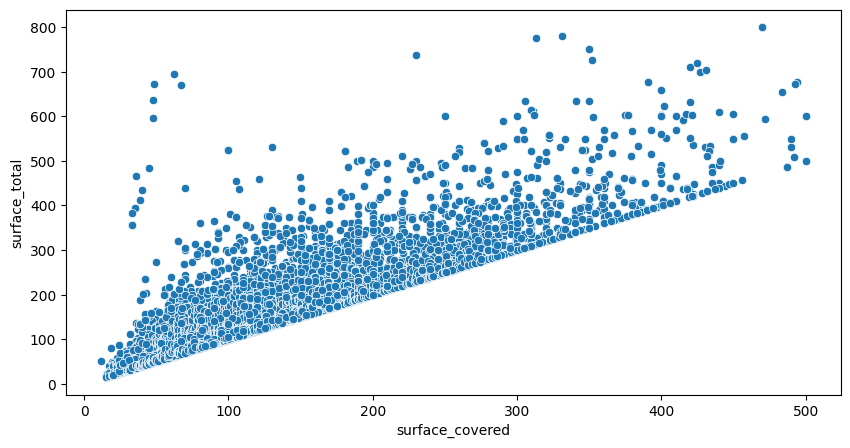

In [96]:
fig = plt.figure(figsize=(10, 5))
sns.scatterplot(data=im8,x='surface_covered',y='surface_total')
plt.show()

Ahora se realizara la imputación de baños. Para esta imputación se usará la relación entre el número de habitaciones y su relación con la cantidad de baños de la propiedad. Para esto se hallará la moda de baños para cada número de habitaciones, es decir, se filtrará los valores que tengan el mismo número de habitaciones y se hallara la moda de los baños, con esta relación se realizará la imputación de los valores de baño.

In [97]:
from scipy import stats
moda = []

for i in range(1, 13):
    a = im8[im8['rooms'] == i]
    b = a['bathrooms'].dropna().to_numpy()
    if len(b) == 0:
        moda.append(np.nan)
    else:
        mode_r = stats.mode(b, axis=None, keepdims=True)
        moda.append(int(mode_r[0][0]))

def imputbh(num_rooms):
    if pd.isna(num_rooms) or not isinstance(num_rooms, (int, float)) or not (1 <= num_rooms <= 12):
        return np.nan
    return moda[int(num_rooms) - 1]

im8['baños2'] = im8['rooms'].apply(imputbh)
im8['bathrooms'] = im8['bathrooms'].fillna(im8['baños2'])
del im8['baños2']
im8.isna().sum()

,0
start_date,0
end_date,0
lat,4312
lon,4326
l3,0
rooms,0
bedrooms,0
bathrooms,0
surface_total,8650
surface_covered,0


Una vez realizada la imputación de los valores faltantes para los atributos que se usaran, se procede al analisis de variables y creación de modelos.

### Precio por metro cuadrado de superficie cubierta

In [98]:
pm2= im8.price/im8.surface_covered
im9=im8.copy()

im9['price_m2']=pm2

Una vez conociendo los datos de precio por metro cuadrado, se realiza un boxplot por barrio para conocer la distribución de precio por metro cuadrado de cada barrio.

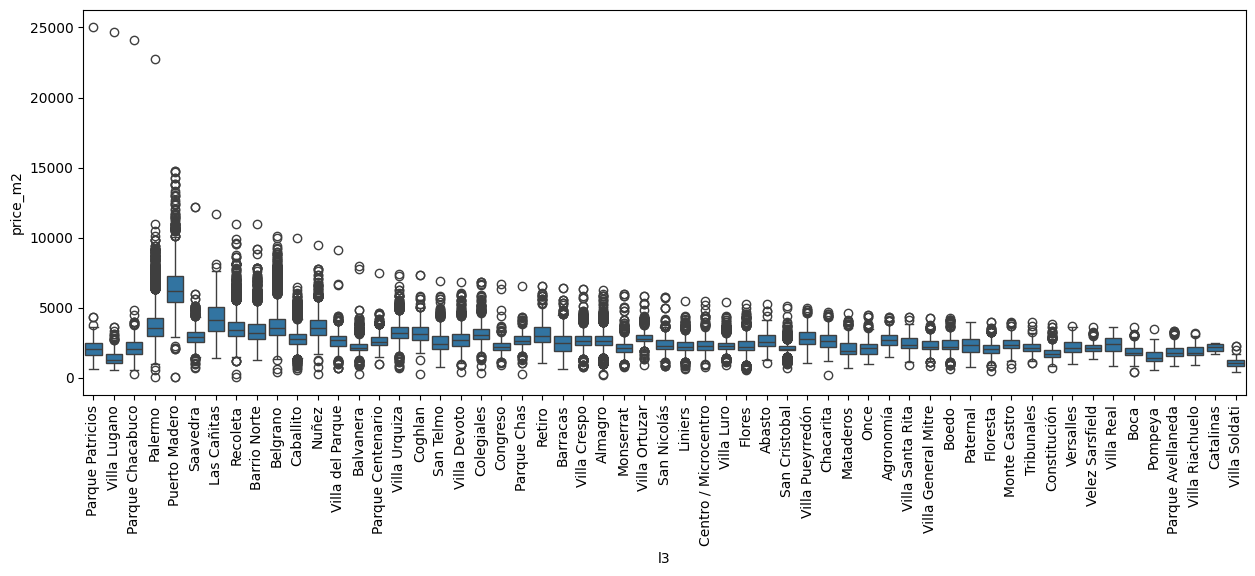

In [99]:
fig = plt.figure(figsize=(15, 5))
order=im9.sort_values(by=['price_m2'], ascending = False)
sns.boxplot(data=order,x='l3',y='price_m2')
plt.xticks(rotation=90)
plt.show()

Se identifican ciertos outliers de la grafica, se decide eliminarlos al ser solo 3.

In [100]:
im9=im9[im9['price_m2']<20e3]

Esta información se utilizara para realizar grupos de barrios con precio por metro cuadrado similar, esto en orden de obtener menor cantidad de atributos a la hora de realizar el modelo de predicción.

In [101]:
pmm2=[]
for i in barrios:
    a=im9['l3'].str.fullmatch(i)
    nvv=im9[a]
    pmm2.append(nvv['price_m2'].sum()/len(nvv))

mm2={'barrios':barrios,'meanprice_m2': pmm2}
mm2=pd.DataFrame(mm2)
mm2=mm2.sort_values(by=['meanprice_m2'], ascending = False)
mm2=mm2.reset_index()
mm2=mm2.drop(columns=['index'])
mm2.head()

,barrios,meanprice_m2
0,Puerto Madero,6447.323873
1,Las Cañitas,4283.677867
2,Palermo,3768.780673
3,Belgrano,3743.016454
4,Nuñez,3644.155820


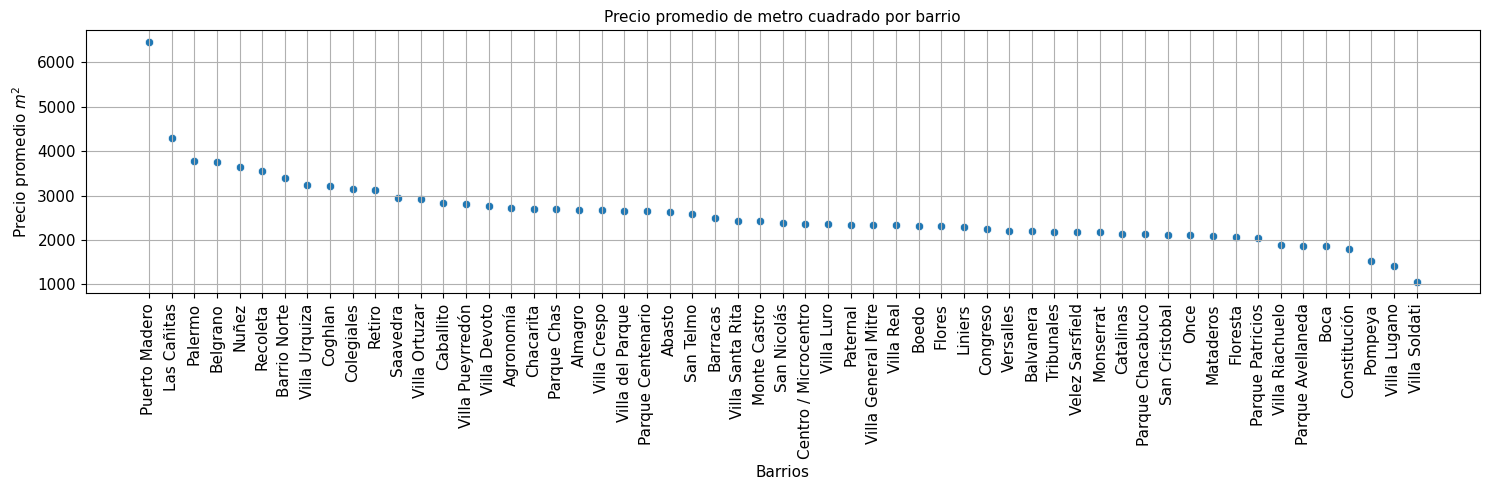

In [102]:
plt.figure(figsize=(15, 5))
plt.subplot(111)
sns.scatterplot(data=mm2,y='meanprice_m2',x='barrios')
plt.ylabel("Precio promedio $m^{2}$",fontsize=11)
plt.xlabel("Barrios",fontsize=11)
plt.xticks(rotation=90)
plt.title('Precio promedio de metro cuadrado por barrio',fontsize=11)
plt.tick_params(labelsize=11)
plt.grid()

plt.tight_layout()

Una vez identificado el promedio de precio cuadrado por barrio como muestra en la anterior grafica, se crearan 5 etiquetas para los barrios con promedio de metro cuadrado similar.

In [103]:
etq=[]
for i in range(5):
    m=np.ones(11)
    m=m*i
    for i in range(11):
        etq.append(m[i])

etq.append(2)
etq.append(3)
etq=np.sort(np.array(etq))
mm2['etq']=etq.astype(int)

Una vez conociendo la etiqueta por barrio, se aplica al dataset original

In [104]:
l33=np.array(im9['l3'])

def etq(l3):
    for i in barrios:
        if l3==i:
            a=mm2['barrios'].str.fullmatch(i)
            b=mm2[a]
            c=b.etq
    return c.values[0]

etiquet=[]

for i in range(im9.shape[0]):
    a=etq(l33[i])
    etiquet.append(a)

im9['etiqueta']=etiquet

In [105]:
im9.head()

,start_date,end_date,lat,lon,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,title,description,property_type,price_m2,etiqueta
0,2019-10-17,2019-12-23,-34.605880,-58.384949,San Cristobal,7.0,7.0,2.0,140.0,140.0,153000.0,"***Venta semipiso centro, ideal hostel*****",DESCRIPCION DE LA PROPIEDAD: Departamento de 1...,Departamento,1092.857143,3
1,2019-10-17,2019-11-21,-34.624056,-58.412110,Boedo,2.0,1.0,2.0,70.0,58.0,159000.0,Espectacular PH reciclado en Boedo sin expensas.,PH reciclado en Boedo a una cuadra de la plaz...,PH,2741.379310,3
2,2019-10-17,2019-11-01,-34.593569,-58.427474,Palermo,2.0,1.0,1.0,45.0,45.0,125000.0,Depto.tipo casa de 2 ambientes en Venta en Pal...,"2 ambienets amplio , excelente estado , patio ...",PH,2777.777778,0
3,2019-10-17,2019-12-23,-34.581294,-58.436754,Palermo,2.0,1.0,1.0,85.0,50.0,295000.0,COSTA RICA 5800 / PALERMO HOLLYWOOD / VENTA PH...,HERMOSO PH EN PALERMO!!!2 AMBIENTES TOTALMENTE...,PH,5900.000000,0
4,2019-10-17,2019-11-01,-34.593779,-58.441239,Villa Crespo,2.0,1.0,1.0,56.0,56.0,150000.0,Depto.tipo casa de 2 ambientes en Venta en Vil...,"Excelente ph solo 2 unidades, no paga expensas...",PH,2678.571429,1


Usando las nuevas etiquetas se grafica precio vs superficie cubierta para ver qué nos muestran las etiquetas.

<Axes: xlabel='price', ylabel='surface_covered'>

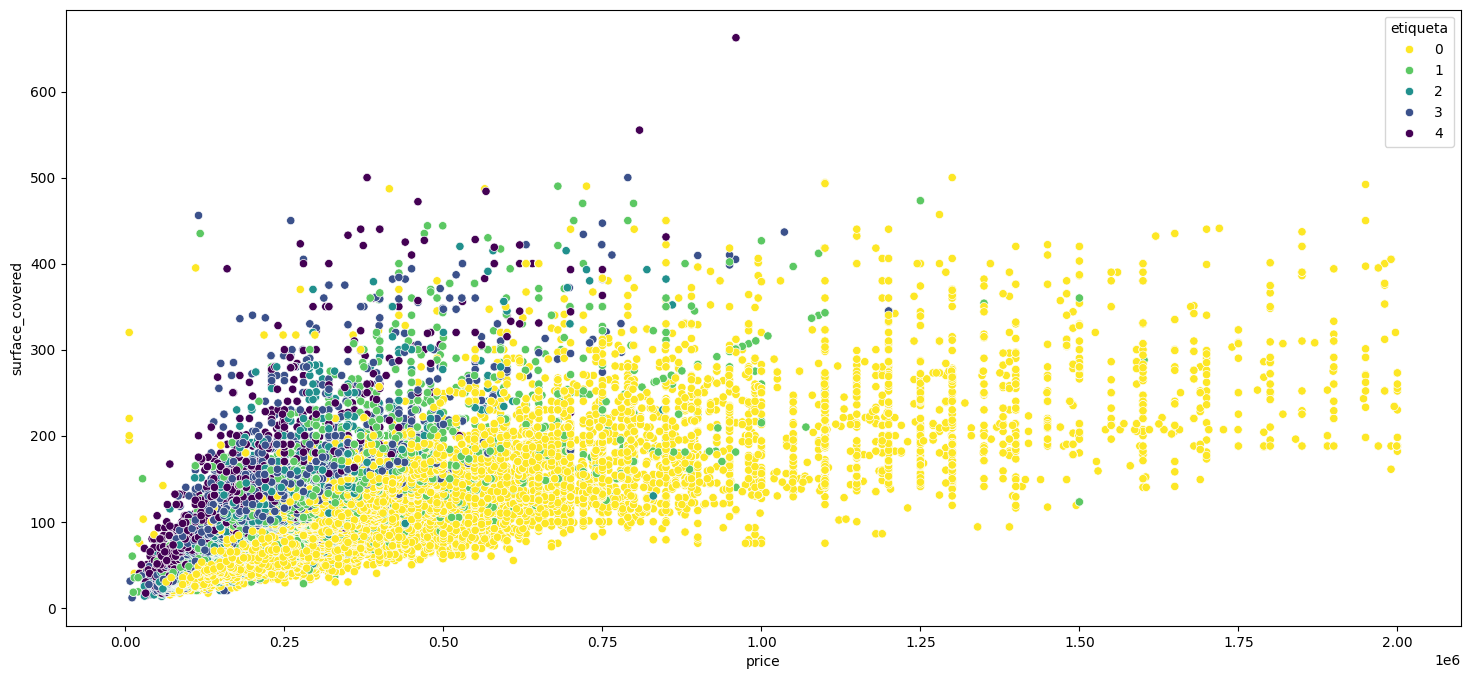

In [106]:
sns.scatterplot(data=im9,x='price',y='surface_covered',hue='etiqueta',palette="viridis_r")

Hay datos que en la grafica parecieran no tener mucho sentido, un ejemplo de esto son aquellos datos que parece tener una gran superficie cubierta y precio muy bajo pero tienen la etiqueta de los barrios con mayor valor por metro cuadrado, esto significa que existe la posibilidad de la existencia de datos mal clasificados en el dataset. Veamos con más claridad cuales son estos datos que identificamos.

In [107]:
fil=im9[np.logical_and(im9.surface_covered>180,im9.price<0.1e6)]
fil

,start_date,end_date,lat,lon,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,title,description,property_type,price_m2,etiqueta
40100,2019-03-28,2019-03-30,-34.581950,-58.401669,Palermo,5.0,4.0,4.0,340.0,320.0,6000.0,Mariscal Ramon Castilla 2800 - Palermo Chico,Exclusivo piso de 320m2 con 4 dormitorios empl...,Departamento,18.750000,0
61397,2019-11-06,2019-12-23,NaN,NaN,Puerto Madero,5.0,3.0,3.0,195.0,195.0,6000.0,RENOIR 2 - 3 DORMITORIOS EN SUITE - PUERTO MAD...,"En piso alto, 3 suites con dependencia. Se alq...",Departamento,30.769231,0
64520,2019-04-30,2019-05-11,-34.591283,-58.389310,Recoleta,3.0,2.0,2.0,340.0,200.0,6000.0,Alquiler Dúplex 3 Amb. Con Terraza y Pileta,Corredor Responsable: GABRIELA FERNANDEZ - CPI...,Departamento,30.000000,0
73676,2019-03-15,2019-06-23,-34.611075,-58.362588,Puerto Madero,3.0,2.0,3.0,275.0,220.0,6000.0,Retasado Bajo el Valor Triplex impecable en Lo...,EXCELENTE triplex de 3 ambientes.En el primer ...,Departamento,27.272727,0


De estos datos se observa que tienen el mismo valor de precio el cual es el valor minimo del data set, esto podria indicar que estos valores de precio realmente deberian ser valores faltantes porque evidentemente no representan la realidad del inmueble y solo parece estar diligenciado para completar el registro. Esto significa que existe la posibilidad de que existan más propiedades donde el precio deberia ser un valor faltante pero estan completados con valores arbitrarios. Para este proyecto se limitara a eliminar estos valores que se lograron identificar.

In [108]:
im10=im9.drop(fil.index)
im10.shape,im9.shape

((88239, 16), (88243, 16))

### Implementación de modelos

In [109]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV


MMS=MinMaxScaler(feature_range = (0, 1))

#### 1. Modelo proyecto 1

Para este modelo se usaron como atributos longitud, latitud, habitaciones, dormitorios, baños, superficie total y superficie cubierta para realizar la predicción de precio con arbol de decisión. Como el modelo usa arbol de decisión se considera que el escalado de datos no tendra gran influencia en la eficiencia del modelo y por lo tanto se omite.

In [110]:
im10.describe()

,lat,lon,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,price_m2,etiqueta
count,83928.000000,83914.000000,88239.000000,88239.000000,88239.000000,79589.000000,88239.000000,8.823900e+04,88239.000000,88239.000000
mean,-34.599080,-58.436130,2.941273,1.942735,1.531194,92.727274,79.259835,2.438145e+05,3029.650027,1.077539
std,0.023972,0.036222,1.265309,1.041304,0.809503,69.976719,54.422916,2.237870e+05,1124.078162,1.231852
min,-34.696419,-58.530468,1.000000,0.000000,1.000000,15.000000,11.669592,7.500000e+03,180.000000,0.000000
25%,-34.613846,-58.459759,2.000000,1.000000,1.000000,49.000000,44.241499,1.200000e+05,2309.523810,0.000000
50%,-34.599400,-58.433823,3.000000,2.000000,1.000000,70.000000,62.000000,1.750000e+05,2828.571429,1.000000
75%,-34.584225,-58.410376,4.000000,3.000000,2.000000,110.000000,94.000000,2.750000e+05,3493.975904,2.000000
max,-34.535818,-58.353930,12.000000,10.000000,7.000000,800.000000,662.545053,2.000000e+06,14787.234043,4.000000


In [111]:
mp1=im10.drop(columns=['l3','property_type','price_m2','etiqueta'],inplace=False)
mp1=mp1.dropna()

Xmp1=mp1.drop("price", axis=1)
ymp1=mp1[['price']]

Xmp1_train, Xmp1_test, ymp1_train, ymp1_test = train_test_split(Xmp1, ymp1, test_size=0.30, random_state=42)
print(Xmp1_train.shape, ymp1_train.shape, Xmp1_test.shape, ymp1_test.shape)

(52865, 11) (52865, 1) (22657, 11) (22657, 1)


In [112]:
def tree_regressorrmse(X_train,y_train,X_test,y_test):
    lismse_train_ar=[]
    lismse_test_ar=[]
    [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,20,25,30,35,40,50]

    for i in lista:
        tree_regressor = DecisionTreeRegressor(max_depth=i, random_state=42)
        tree_regressor.fit(X_train, y_train)

        y_train_pred_ar = tree_regressor.predict(X_train)
        y_test_pred_ar = tree_regressor.predict(X_test)

        rmse_train_ar = np.sqrt(mean_squared_error(y_train, y_train_pred_ar))
        rmse_test_ar =np.sqrt(mean_squared_error(y_test, y_test_pred_ar))

        lismse_train_ar.append(rmse_train_ar)
        lismse_test_ar.append(rmse_test_ar)
    return lismse_train_ar,lismse_test_ar

lista=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,20,25,30,35,40,50]
plt.figure(figsize=(8, 5))
plt.plot(lista,tree_regressorrmse(Xmp1_train,ymp1_train,Xmp1_test,ymp1_test)[0],'o-',label='train' )
plt.plot(lista,tree_regressorrmse(Xmp1_train,ymp1_train,Xmp1_test,ymp1_test)[1],'o-',label='test')
plt.legend()
plt.xlabel('Profundidad arbol')
plt.ylabel('RMSE')

ValueError: could not convert string to float: '2019-10-17'

<Figure size 800x500 with 0 Axes>

In [ ]:
tree_regressor = DecisionTreeRegressor(max_depth=10, random_state=42)
tree_regressor.fit(Xmp1_train, ymp1_train)

ymp1_train_pred = tree_regressor.predict(Xmp1_train)
ymp1_test_pred = tree_regressor.predict(Xmp1_test)

In [ ]:
rmse_train = np.sqrt(mean_squared_error(ymp1_train, ymp1_train_pred))
rmse_test = np.sqrt(mean_squared_error(ymp1_test, ymp1_test_pred))

print(f'Raíz del error cuadrático medio en Train: {rmse_train}')
print(f'Raíz del error cuadrático medio en Test: {rmse_test}')

x=np.arange(0,2e6)

plt.figure(figsize=(10, 8))

plt.subplot(221)
plt.scatter(ymp1_train,ymp1_train_pred,s=2)
plt.plot(x,x,color='k', alpha=0.75, zorder=0)
plt.xlabel('y',fontsize=11)
plt.ylabel('y_pred',fontsize=11)
plt.title('Train',fontsize=14)

plt.subplot(222)
plt.scatter(ymp1_test,ymp1_test_pred,s=2)
plt.plot(x,x,color='k', alpha=0.75, zorder=0)
plt.xlabel('y',fontsize=11)
plt.ylabel('y_pred',fontsize=11)
plt.title('Test',fontsize=14)

plt.tight_layout()
plt.show()

Para comparar los modelos recordemos el resultado obtenido con el dataset filtrado del proyecto 1:


<img src="proyecto1modelo.png" width="600" height="400">


Hay varios puntos a tener en cuenta, uno de ellos y el que más se resalta es que el error para este dataset es menor a comparación del dataset resultante en el proyecto 1, esto parece indicar que el preprocesamiento de este dataset ayudó a mejorar el funcionamiento del modelo, además la diferencia entre el error en train y test es mucho menor lo cual indica menor sobreajuste del modelo en su valor optimo. También se puede notar que la dispersion de los datos predichos es un tanto menor, esto quiere decir que si bien hay datos que no se predijeron con exactitud, estos parecen mantenerse dentro de una franja de error, si se compara esto con el proyecto anterior se encuentra cierta diferencia puesto que ese se ven datos muy alejados de su valor real y que su error pareciera ser mayor al de la raiz del error cuadratico medio.

#### 2. Modelos avanzados

Inicialmente preparamos la columna etiquetas con un one hot encoder en caso de usarlas en el modelo.

In [ ]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown="ignore")

encoderr=pd.DataFrame(encoder.fit_transform(im10[['etiqueta']].astype('category')).toarray())
encoderr.head()

Revisamos de nuevo la correlación entre variables para decidir cuales son los atributos que se usaran.

In [ ]:
fc=im10.drop(columns=['lat','lon','l3','price_m2','etiqueta'],inplace=False)

corr = fc.drop(columns = 'property_type').corr()
plt.figure(figsize=(8,8))
sns.heatmap(corr, cbar = True,  square = True, annot=True, fmt= '.2f',annot_kws={'size': 15},
           xticklabels= fc.drop(columns = 'property_type').columns,
           yticklabels= fc.drop(columns = 'property_type').columns,
           cmap= "rocket_r")
plt.xticks(rotation = 45)
plt.yticks(rotation = 45)
plt.show()

##### 2.1 Regresión avanzada

La siguiente es una función para graficar los errores y comparar la predicción con los datos.

In [ ]:
def evaluar_regresion(model,x,y, X_train, X_test, y_train, y_test):

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    ### CALCULAMOS EL ERROR
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    mae_train = mean_absolute_error(y_train, y_train_pred)

    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mae_test = mean_absolute_error(y_test, y_test_pred)


    print(f'Raíz del error cuadrático medio en Train: {rmse_train}')
    print(f'Raíz del error cuadrático medio en Test: {rmse_test}')

    print(f'error absoluto medio en Train: {mae_train}')
    print(f'error absoluto medio en Test: {mae_test}')

    plt.figure(figsize=(15, 5))

    plt.subplot(1,2,1)
    sns.histplot(y_train - y_train_pred, bins = 40, label = 'train',kde=True,color='red')
    sns.histplot(y_test - y_test_pred, bins = 40, label = 'test',kde=True)
    plt.xlabel('errores')
    plt.title('Errores precio')
    plt.legend()

    ax = plt.subplot(1,2,2)
    ax.scatter(y_test,y_test_pred, s =2)

    lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes]
    ]

    ax.plot(lims, lims, 'k-', alpha=0.75, zorder=0)
    plt.xlabel('y (test)')
    plt.ylabel('y_pred (test)')
    plt.title('Precio original vs precio predicho')

    plt.tight_layout()
    plt.show()

Para el modelo de regresión se considera usar los atributos superficie cubierta, baños y las etiquetas, esto debido a que superficie cubierta y baños tienen gran correlación con precio pero poca correlación entre ellas asi que son variables diferentes que pueden ser de gran ayuda, y las etiquetas porque nos relacionan el valor del metro cuadrado con ciertos barrios, sin embargo, como es una regresión, no tiene mucho sentido poner estas variables categoricas como atributos, asi que en su lugar se usará el promedio de metro cuadrado del barrio en el que se encuentra la propiedad como atributo.

In [ ]:
l33=np.array(im10['l3'])

def pm2(l3):
    for i in barrios:
        if l3==i:
            a=mm2['barrios'].str.fullmatch(i)
            b=mm2[a]
            c=b.meanprice_m2
    return c.values[0]

pm22=[]

for i in range(im10.shape[0]):
    a=pm2(l33[i])
    pm22.append(a)

im10['promm2']=pm22
im10=im10.drop(columns=['price_m2'],inplace=False)
im10=im10.reset_index()
im10

In [ ]:
#sc=im10[['surface_covered']]
#tr=MMS.fit_transform(sc)

#X1=im10[['bathrooms','promm2']]
#X1=X1.join(pd.DataFrame(tr))

#xx=im10[['surface_covered','bathrooms','promm2','lat','lon','price']]
#xx=xx.dropna()

#X1=xx[['surface_covered','bathrooms','promm2','lat','lon']]
X1=im10[['surface_covered','bathrooms','promm2']]
#X1=MMS.fit_transform(X1)

#y1=xx[['price']]
y1=im10['price']

X1

In [ ]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.30, random_state=42)
print(X1_train.shape, y1_train.shape, X1_test.shape, y1_test.shape)

Para la optimización de hiperparametros se realiza una validación cruzada con 10 k-folds para polinomios de grado 1 a 15, la metrica para evaluar el hiperparametro más optimo será la raiz del error cuadratico medio, esto debido a que nos centraremos en darle importancia a los errores grandes de la predicción, es decir, los valores que más difieran de la predicción tendran un peso mayor, por lo tanto el hiperparametro que tenga menor raiz del error cuadratico medio es el que genera una predicción con menor error en aquellos datos que difieren mucho de su valor real.

###### Regresion polinomial

In [ ]:
from sklearn.pipeline import Pipeline
import scipy as sp

pipe = Pipeline(steps=[
    ('poly', PolynomialFeatures(include_bias=False)),
    ('model', LinearRegression()),
])

polgrid=GridSearchCV(
    estimator=pipe,
    param_grid={'poly__degree': np.arange(1, 15)},
    cv=10,scoring='neg_root_mean_squared_error'
)

In [ ]:
polgrid.fit(X1_train, y1_train)

In [ ]:
print("Mejores parametros: "+str(polgrid.best_params_))
print("Mejor Score, raíz del error cuadrático medio en Train: "+str(-polgrid.best_score_))

prediction = polgrid.predict(X1_test)
prediction

"""
filter_arr = []

for element in prediction:
    if element < 3e6:
        filter_arr.append(True)
    else:
        filter_arr.append(False)

prediction = prediction[filter_arr]
y1_test=y1_test[filter_arr]
"""

rmse = np.sqrt(mean_squared_error(y1_test, prediction))
print(f'Raíz del error cuadrático medio en Test: {rmse}')

La grilla nos arroja que el hiperparametro que genera mejores resultados para el regresor polinomial es un polinomio de grado 4, procedemos a graficar los errores y a comparar los datos predichos con los originales.

In [ ]:
evaluar_regresion(polgrid, X1,y1, X1_train, X1_test, y1_train, y1_test)

Se obtiene una raiz del error cuadratico medio alta, sin embargo la diferencia entre el error en train y test es muy poca y por lo tanto se considera que la predicción tiene un menor sobreajuste a comparación de los modelos antes evaluados, los errores son relativamente simetricos sin embargo pareciera que el modelo tiende a asignarle un valor menor de precio a las propiedades, ademas de ciertos valores en la predicción que no tienen mucho sentido tales como el valor negativo que se aprecia en la grafica de precio predicho vs precio original. Sin embargo al ser solo un valor que muestra este comportamiento, se podria considerar que quizá sea un valor atipico en alguno de los atributos de la base de datos original o simplemente que el modelo no genera una buena predicción para ciertas instancias en especifico. El modelo se intento probar con un escalado de datos de superficie cubierta pero el error resultante era mayor asi que se descartó. También se intento probrar escalando todos los atributos de X pero aunque el error era un poco menor, el modelo genero más datos atipicos, como una propiedad la cual tenia un precio original de aproximandamente 1e6 dolares con un precio predecido de unos 6e6 dolares, por lo tanto se decidio tomar el modelo sin escalar los datos.

###### Regresion Regularización Ridge

In [ ]:
from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV

Se realiza la busqueda de hiperparametros optimos para la regresion Ridge, para esto se toma un rango logaritmico que de una gran variedad de datos de distintos valores, además se escoge normalizar los datos y hallar el intercepto.

In [ ]:
L2= RidgeCV(
            alphas          = np.logspace(-10, 3, 300),
            fit_intercept   = True,
            store_cv_results = True
         )

L2.fit(X = X1_train, y = y1_train)

In [ ]:
print('El valor de alpha/lambda que escogio como optimo el cross validation para el metodo de regularización \n',
      'L2 Ridge es:', L2.alpha_)
print(' ')
print('Los coeficientes para cada atributo:\n superficie cubierta', L2.coef_[0],'\n','baños',L2.coef_[1],'\n',
      'Precio promedio metro cuadrado',L2.coef_[2])

In [ ]:
evaluar_regresion(L2, X1,y1, X1_train, X1_test, y1_train, y1_test)

En general el modelo de regularización pareciera tender a tener un lambda cercano a 0, esto significa que parece que el modelo se comporta mejor cuando tiende a una regresión lineal. Valores tan pequeños de lambda indican sobreajuste pero al comparar los errores de train y test estos son similares asi que pareciera indicar que la varianza no es tan grande, por esto se concluye que es posible que este indicando, como se mencionaba anteriormente, que el modelo adecuado para estos datos en cuanto a regresion lineal es la regresion lineal sencilla con lambda tendiendo a cero.

En cuanto al error, se ve cierta tendencia de predecir los valores con un precio menor al original, tal como en el modelo anterior pero un tanto más pronunciado para este modelo.

##### 2.2 Random forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

Para el random forest no se evaluara una grilla especifica sino que se realizara una evaluacion aleatoria con algunos de los valores estipulados, de ahí el modelo escogera los mejores hiperaparamentros para el modelo.

###### datos 1

Para esta parte inicialmente se usará de nuevo los valores de X y y escogidos anteriormente, para este caso no se escalaran los datos debido al tipo de modelo.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

n_estimators = [1, 5, 10, 15, 20, 25,30, 35, 40, 45, 50, 55,
                60, 65, 70, 75, 80, 85,90, 95, 100]

max_features = ['sqrt','log2']

max_depth = [int(x) for x in np.linspace(10, 100, 10)]
max_depth.append(None)

min_samples_split = [2,3,4,5,8,10]

min_samples_leaf = [1,2,3,4,5]

bootstrap = [True]

random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}

rf = RandomForestRegressor()

In [ ]:
rf_random1 = RandomizedSearchCV(estimator = rf, param_distributions = random_grid, cv = 3,
                               random_state=42,scoring='neg_root_mean_squared_error')

rf_random1.fit(X1_train, y1_train)

rf_random1.best_estimator_

Luego de evaluar obtenemos el mejor estimador y con este se mirara la importancia de los features.

In [ ]:
AA=rf_random1.best_estimator_
AA.fit(X1_train, y1_train)
AA.feature_importances_

El primer valor corresponde a superficie cubierta, el segundo a baños y el tercero a precio promedio del metro cuadrado por barrio. De acuerdo al modelo se obtiene que el atributo más importante para el modelo es el de superficie cubierta, los otro dos también cuentan con cierta importancia significativa pero no comparable con la de superficie cubierta.

Evaluemos ahora el modelo.

In [ ]:
evaluar_regresion(rf_random1, X1,y1, X1_train, X1_test, y1_train, y1_test)

La diferencia entre la raiz del error cuadratico medio en train y test parece indicar que el modelos esta sobreajustando los datos de train y por lo tanto al entrenarlo con test, los resultados muestran mayor error. Aun así los datos de los errores parecen ser simetricos en igual proporcion lo cual difiere del modelo de regresión anteriormente evaluado. Algo a tener en cuenta es que este modelo tiene un error absoluto medio menor que los otros, es decir que en general si a todos los datos se les da el mismo peso, el error tiende a ser menor y esto parece indicar que la dispersion de los datos es menor que en los anteriores modelos.

###### datos 2

Ahora evaluemos el modelo de random forest pero con diferentes atributos, esta vez se eliminará el valor de precio por metro cuadrado promedio del barrio al que pertenece y se utilizaran las etiquetas que clasificaban los barrios dependendiendo de su valor por metro cuadrado promedio.

In [ ]:
X2=X1.drop(columns=['promm2'],inplace=False)
X2=X2.join(pd.DataFrame(encoderr))
X2.columns = X2.columns.astype(str) # Convert all column names to strings
y2=y1

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.30, random_state=42)
print(X2_train.shape, y2_train.shape, X2_test.shape, y2_test.shape)

In [ ]:
X2.head()

In [ ]:
rf_random2 = RandomizedSearchCV(estimator = rf, param_distributions = random_grid, cv = 3,
                               random_state=42,scoring='neg_root_mean_squared_error')

rf_random2.fit(X2_train, y2_train)

rf_random2.best_estimator_

De nuevo, se evalua el modelo obtenido para revisar la importancia de cada feature.

In [ ]:
AA2=rf_random2.best_estimator_
AA2.fit(X2_train, y2_train)
AA2.feature_importances_

Los dos primeros datos pertenecen a superficie cubierta y baños, respectivamente. Los otros datos pertenecen a las etiquetas del 0 al 4 respectivamente, de estas ultimas hay algo para resaltar y es que pareciera que la importancia del feature fuera mayor para los barrios clasificados con mayor precio por metro cuadrado y fuera disminuyendo a medida que la etiqueta cambiaba y por lo tanto el valor del precio por metro cuadrado asociado a esa etiqueta. Es decir que para el modelo pareciera es más util reconocer cuales son las instancias con mayor valor de metro cuadrado asociado.

Ahora evaluemos.

In [ ]:
evaluar_regresion(rf_random2, X2,y2, X2_train, X2_test, y2_train, y2_test)

Para este caso el modelo tiene una raiz del error cuadratico medio mayor, sin embargo la diferencia entre el error en test y en train es menor lo que parece indicar que no hay tanto sobreajuste como en el modelo anterior. El error absoluto medio es un tanto mayor en este caso lo cual tiene sentido porque el error cuadratico medio también es mayor, es decir, en general este modelo tiene más error. Los errores parecieran ser simetricos pero los que suelen ser más alejados del valor real pareciera tienden a ser precios que se predicen con un valor muy por debajo del real, tal como en los anteriores modelos.

##### 2.2 Arbol de decision

Por ahora parece que el modelo que mejor ha dado resultados sigue siendo el arbol de decisión, asi que evaluemoslo en los datos  que contienen solo superficie cubierta, baños y precio por metro cuadrado del barrio.

In [ ]:
dt=GridSearchCV(
    estimator=DecisionTreeRegressor(),
    param_grid={'max_depth': np.arange(1, 25),'min_samples_split':[2,5,8],
               'min_samples_leaf':[1,3,5],'max_features':['auto', 'sqrt', 'log2',None]},
    cv=5,scoring='neg_root_mean_squared_error'
)
dt.fit(X1_train, y1_train)

In [ ]:
dt.best_estimator_

In [ ]:
evaluar_regresion(dt, X1,y1, X1_train, X1_test, y1_train, y1_test)

Si bien el error es menor, parece que el modelo tiende a realizar un sobreajuste en los datos. Veamos como se comporta si realizamos la seleccion de hiperparametros de forma manual.

In [ ]:
lista= [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,20,25,30,35,40,50]
plt.figure(figsize=(8, 5))
plt.plot(lista,tree_regressorrmse(X1_train,y1_train,X1_test,y1_test)[0],'o-',label='train' )
plt.plot(lista,tree_regressorrmse(X1_train,y1_train,X1_test,y1_test)[1],'o-',label='test')
plt.legend()
plt.xlabel('Profundidad arbol')
plt.ylabel('RMSE')

In [ ]:
tree_regressor2 = DecisionTreeRegressor(max_depth=11)
tree_regressor2.fit(X1_train, y1_train)

evaluar_regresion(tree_regressor2, X1,y1, X1_train, X1_test, y1_train, y1_test)

Los datos parecen mejorar en cuanto al hecho de que no hay tanto sobreajuste como en el modelo escogido por la grilla, sin embargo la raiz del error medio es mayor.

###### Recordemos lo obtenido con los anteriores atributos

In [ ]:
print(f'Raíz del error cuadrático medio en Train: {rmse_train}')
print(f'Raíz del error cuadrático medio en Test: {rmse_test}')

mae_train = mean_absolute_error(ymp1_train, ymp1_train_pred)
mae_test = mean_absolute_error(ymp1_test, ymp1_test_pred)

print(f'Error absoluto medio en Train: {mae_train}')
print(f'Error absoluto medio en Test: {mae_test}')

x=np.arange(0,2e6)

plt.figure(figsize=(10, 8))

plt.subplot(221)
plt.scatter(ymp1_train,ymp1_train_pred,s=2)
plt.plot(x,x,color='k', alpha=0.75, zorder=0)
plt.xlabel('y',fontsize=11)
plt.ylabel('y_pred',fontsize=11)
plt.title('Train',fontsize=14)

plt.subplot(222)
plt.scatter(ymp1_test,ymp1_test_pred,s=2)
plt.plot(x,x,color='k', alpha=0.75, zorder=0)
plt.xlabel('y',fontsize=11)
plt.ylabel('y_pred',fontsize=11)
plt.title('Test',fontsize=14)

plt.tight_layout()
plt.show()

El error es menor para los atributos iniciales que contenian la longitud y latitud, sin embargo para los atributos que contienen en su lugar el precio por metro cuadrado el modelo parece tener un menor sobreajuste.

###### Recopilación de resultados

In [ ]:
def modelos(model,x,y, X_train, X_test, y_train, y_test):

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    mae_train = mean_absolute_error(y_train, y_train_pred)

    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mae_test = mean_absolute_error(y_test, y_test_pred)
    return rmse_train, rmse_test, mae_train, mae_test


errortr=modelos(tree_regressor, Xmp1, ymp1, Xmp1_train, Xmp1_test, ymp1_train, ymp1_test)
errortrp1=[86801,110486,np.nan,np.nan]
errortrdt=modelos(dt,X1,y1, X1_train, X1_test, y1_train, y1_test)
errortr2=modelos(tree_regressor2, X1, y1, X1_train, X1_test, y1_train, y1_test)
errorpolgrid=modelos(polgrid, X1, y1, X1_train, X1_test, y1_train, y1_test)
errorll2=modelos(L2, X1, y1, X1_train, X1_test, y1_train, y1_test)
errorrandomforest1=modelos(rf_random1, X1, y1, X1_train, X1_test, y1_train, y1_test)
errorrandomforest2=modelos(rf_random2, X2,y2, X2_train, X2_test, y2_train, y2_test)

erroresrmsetrain=[]
erroresrmsetest=[]
erroresmatrain=[]
erroresmatest=[]
e=[erroresrmsetrain,erroresrmsetest,erroresmatrain,erroresmatest]

for i in range(0,4):
    a=[errortr[i],errortrp1[i],errortrdt[i],errortr2[i],errorpolgrid[i],errorll2[i],errorrandomforest1[i],errorrandomforest2[i]]
    e[i].append(a)


modeloss=['Árbol de decisión','Árbol de decisión P1','Árbol de decisión','Árbol de decisión','Regresión polinomica',
          'Regularizacion Ridge','Random Forest','Random Forest']
datoss=['datos0','datos0','datos1','datos1','datos1','datos1','datos1','datos2']
evaluacion=['Manual','Manual','Grilla','Manual','Grilla','Grilla','RandomSearch','RandomSearch']

erroresd={'Modelo': modeloss ,'Datos': datoss, 'Evaluacion': evaluacion
          , 'RMSE Train': erroresrmsetrain[0],'RMSE Test': erroresrmsetest[0],
          'MAE Train': erroresmatrain[0],'MAE Test': erroresmatest[0]}
erroresd=pd.DataFrame(erroresd)

Para lo siguiente vamos a tener en cuenta 3 tipos de datos:

1. datos0: estos son los datos con los que se evaluaron el modelo que tuvo mejor performance en el proyecto 1, es decir datos con los atributos longitud, latitud, habitaciones, dormitorios, baños, superficie total y superficie cubierta.


2. datos1: atributos de superficie cubierta, baños y precio promedio de metro cuadrado por barrio


3. datos2: atributos de superficie cubierta, baños y etiquetas por barrios.

In [ ]:
erroresd

En cuanto a árbol de decisión P1 se hace referencia al modelo evaluado con los datos del proyecto 1, es decir aquellos con un preprocesamiento diferente.

1. Árbol de decisión:

Inicialmente con los atributos de datos0 se ve una mejoria en el performance del modelo de árbol de decisión para los datos con el prepocesamiento realizado en este proyecto, el error es considerablente menor y la diferencia entre este también, lo que indica un menor sobreajuste.

Para la evaluación de árbol de decisión con los atributos de datos1 se observa un buen performance para Train pero un mayor error al evaluarlo en test con la grilla, esto indica que hay sobreajuste en los datos de prueba, sin embargo el error medio absoluto es un poco menor, lo que indica que en general el error es menor solo que existen ciertos datos con predicciones que difieren mucho del valor original que generan que RMSE sea mayor. Para la evaluación manual de los mismos datos, se tiene un mejor performance en cuanto al sobreajuste, siendo este menor, pero el error en general es mayor.


2. Regresión avanzada:

Ambos modelos se evaluaron con la grilla para los atributos de datos1 por las razones anteriormente mencionadas, en general los dos modelos representan predicciones que no tienen sobreajuste puesto que el error entre train y test es muy pequeño, sin embargo, lo que parece que da como resultado estos modelos es que a lo que menos se parece el comportamiento de los datos es una regresión lineal, dado que es la que tiene mayor error de todos los modelos por lo menos para los atributos con los que se cuentan. El hecho de que el error para la regresión polinomial sea menor parece afirmar esto.


3. Random Forest:

Para el random forest evaluado con los atributos de datos1, parece que sucede algo similar a lo que sucede con árbol de decisión al evaluarlo en la grilla y es que los datos tienden a sobreajustarse para estos atributos. Sin embargo el error tiende a ser menor y es el modelo con mejor valor de MAE. Ahora, al evaluar el modelo en los atributos de datos2 parece que los datos se sobreajustan menos aunque el error es mucho mayor. Esto puede indicar dos cosas, para los atributos de datos 1 el modelo se pude mejorar al hacer un randomsearch con opciones de hiperparametros que sean más optimos para el modelo o que se pueden agregar atributos que ayuden a hacer más diverso los datos y evite un sobreajuste en el modelo.

In [ ]:
def g(model, X_test, y_test):
    y_test_pred = model.predict(X_test)
    gra=pd.DataFrame({'test':y_test,'testpred':y_test_pred})
    return gra

modeloo=['Árbol desición datos1 grilla','Árbol desición datos1 manual','Regresión Polinomial datos1','Regularización Ridge datos1'
         ,'Random Forest datos1','Random Forest datos2']

modell=[dt,tree_regressor2,polgrid,L2,rf_random1,rf_random2]
xtest=[X1_test,X1_test,X1_test,X1_test,X1_test,X2_test]
ytest=[y1_test,y1_test,y1_test,y1_test,y1_test,y2_test]


In [ ]:
plt.rc('figure', figsize=(10, 10))
fig, axes = plt.subplots(ncols=2, nrows=3)

x=np.arange(0,2e6)
for i, ax in zip(range(6), axes.flat):
    if i<2:
        sns.scatterplot(data = g(modell[i], xtest[i], ytest[i]), x='test',y='testpred' ,ax=ax)
        ax.plot(x,x,color='k')
        ax.set_title(modeloo[i])
        ax.set_xlabel('precio original test')
        ax.set_ylabel('precio predicho test')
    elif i<4:
        sns.scatterplot(data = g(modell[i], xtest[i], ytest[i]), x='test',y='testpred' ,ax=ax)
        ax.plot(x,x,color='k')
        ax.set_title(modeloo[i])
        ax.set_xlabel('precio original test')
        ax.set_ylabel('precio predicho test')
    else:
        sns.scatterplot(data = g(modell[i], xtest[i], ytest[i]), x='test',y='testpred' ,ax=ax)
        ax.plot(x,x,color='k')
        ax.set_title(modeloo[i])
        ax.set_xlabel('precio original test')
        ax.set_ylabel('precio predicho test')

plt.tight_layout()
plt.show()

Comparando las graficas obtenidas de precio original vs precio predicho por modelo es posible identificar más diferencias en los modelos, por ejemplo, los arboles de decisión suelen tener mayor dispersion en los datos a medida que el precio del inmueble aumenta, entre los dos modelos parece que el que mejor tiene comportamiento entre los arboles de decisión es el que se realizo la busqueda de hiperparamentros de forma manual. Para las regresiones avanzadas el modelo de regresión polinomial muestra un muy buen ajuste a pesar de tener un error considerablemente grande, no se ve tanta dispersión en los datos a comparación de los demás modelos. Para los modelos de random forest, los atributos de datos1 parecen generar errores más simetricos y un error menor.

Juntando el analisis de error y la visualización de los resultados, se considera que los mejores modelos para la predicción son el de regresion polinomial, aunque el RMSE sea considerablemente alto el MAE es muy bueno (esta dinamica indica outliers en la predicción, tal como se menciono anteriormente) y los datos no estan sobreajustados, y el árbol de decisión seleccionado de forma manual, hay un poco de sobreajuste pero el RMSE es más pequeño a comparación de los otros modelos. Idealmente se continuaria trabajando con cada uno de los modelos de preferencia para identificar cómo se puede optimizar el modelo. Sin embargo, si se forza a tomar una decisión respecto a qué modelo usar de los anteriores teniendo en cuenta los pro y en contra, se escogeria el de regresión polinomial y se encargaria de estar atento a los posibles outliers.

## Conclusiones

1.  En cuanto al preprocesamiento de los datos, cuando se realizo la exploración de los datos se encontraron datos mal clasificados o en general valores atipicos que no son facilmente identificables por una preprocesamiento superficial, aun asi realizar un filtro de estos datos resulta complicado. Un ejemplo de esto son cocheras identificadas como departamentos, o propiedades con valores muy por debajo de lo habitual teniendo en cuenta el valor promedio de las propiedades por barrio. Para verificar la veracidad de los datos es posible apoyarse de entradas como titulo y descripción, lo cual requiere cierto conocimiento en procesamiento de lenguaje natural.
    

2. Para el analisis de valores outliers es importante revisar la cantidad de datos y la naturaleza de estos al realizar un filtrado por medio de una metrica estadistica, esto debido a que estas se basan en modelos de datos que siguen cierto comportamiento que puede que nuestros datos no cumplan y esto signifique una mala clasificación. Otro factor importante en cuanto a la busqueda de outliers es conocer los atributos los cuales se estan filtrando, por ejemplo en este caso en especifico es importante tener en cuenta cual es el metro cuadrado promedio de la propiedad más grande en la zona urbana de Buenos Aires para tener una idea de qué valores se puede considerar como mal clasificados y hacer un filtro que se adapte a la realidad.


3. Existen muchos más factores a tener en cuenta para crear nuevo atributos que ayuden a la prediccion. Un ejemplo de esto es que se puede mirar la relación del valor del metro cuadrado por ciertos intervalos de tiempo y con esto conocer si los barrios se han valorizado de tal forma que entradas de ciertos años pueden influir de forma diferente en los valores de los datos.


4. En cuanto a la creación de modelos, más allá de tener un atributo que relacione precio, superficie cubierta y barrio (precio promedio de metro cuadrado por barrio), parece que longitud y latitud sigue siento un atributo con gran importancia en el modelo, esto tiene sentido puesto que los valores de las propiedades suelen depender del lugar en el que se encuentren más allá del barrio en especifico, es decir, hay un estandar de precio para cada barrio pero el valor de la propiedad puede variar segun su entorno, es decir, una propiedad que se encuentre cerca de un parque, lejos de una calle principal, cerca a lugares de interes puede tener un precio mayor.


5. De lo obtenido con los modelos evaluados, los rangos de error parecen indicar que el aumento de la complejidad en el modelo no beneficia tanto al performance de este, por ejemplo modelos como random forest da un resultado que genera un sobreajuste en los datos, sin embargo también se puede deber a la simplicidad de las grillas creadas para buscar los hiperparametros optimos de los modelos, esto debido al coste computacional de crear grillas más elaboradas o con mayores posibilidades. El mejor conocimiento de los parametros segun los datos para evaluar los modelos en las grillas también podria ayudar a optimizar el tiempo de respuesta de la evaluación. Se le atribuye esto a la evaluacion de los hiperparametros debido a que en casos como los arboles de decisión donde se puede tener una vista "manual" del error para train y test, es más facil realizar una eleccion donde el error para ambos no sea tan lejano pero en un punto en el que se estabilice el error para test, en este caso la grilla solo pareciera enfocarse en buscar el punto donde se estabiliza más el error para train. Quizá una forma de mejorar esto ultimo seria tomando un valor mayor para los k fold del cross validation, esto con la intención de evaluar mejor la varianza del modelo en diferentes agrupaciones de los datos, sin embargo como se mencionaba antes, esto tiene un coste computacional mayor.

## Anexo

Anteriormente al intentar crear un nuevo atributo con el cual clasificar los datos dependiendo de su barrio y precio se realizo una division según su precio promedio por metro cuadrado, sin embargo también se intento realizar un ejercicio de clusterización para identificar estas etiquetas el cual no se discutio puesto que al hacer las divisiones los valores de precio no parecian tener una agrupación particular adecuada segun lo que se buscaba para este tipo de clasificación, aún así, se anexará el ejercicio de clusterización de los datos como una muestra de los resultado obtenidos para los datos en ese momento del preprocesamiento.

Para este ejercicio se utilizaron los datos de latitud, longitud y precio.

In [ ]:
im11=im8.dropna(subset=['lon', 'lat'])
im11.shape, im8.shape

Como la intencion de esta clusterización es generar categorias que relacionen la pocision geografica y el precio, se usara kmeans.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

Xc=im11[['lon','lat','price']]

Xct = ss.fit_transform(Xc)
Xct

Se realiza la prueba de elbow para identificar la cantidad de cluster optimo.

In [ ]:
# Preparamos una lista donde vamos a ir agregando las distancias medias
Sum_of_squared_distances = []
# Fiteammos un modelo para cada numero de cluster que queremos testear
K = np.arange(1,40,2)
for k in K:
    # Definimos y entrenamos el modelo
    km = KMeans(n_clusters=k)
    km = km.fit(Xct)
    # Calculamos la distancia media y agregamos a la lista
    distancia_total = km.inertia_
    distancia_media = np.divide(distancia_total,Xc.shape[0])
    Sum_of_squared_distances.append(distancia_media)

plt.figure(figsize = (10,7))
plt.plot(K, Sum_of_squared_distances, lw=3)
plt.scatter(K, Sum_of_squared_distances,s=55,c='r')
plt.xlabel('Cantidad de Clusters K')
plt.ylabel('Inercia media')
plt.title('Método del codo para el Dataset 1')

plt.show()

De acuerdo a este metodo se toma el número de custers igual a 6.

In [ ]:
kmeans_1 = KMeans(n_clusters=6, random_state=0)

kmeans_1.fit(Xct)

etiquetas_1 = kmeans_1.labels_
centros_1 = kmeans_1.cluster_centers_

Se crea un nuevo dataset con las etiquetas

In [ ]:
ccl={'lon':Xct[:, 0],'lat': Xct[:, 1], 'price_m2': Xct[:, 2], 'etiquetas':etiquetas_1}
ccl=pd.DataFrame(ccl)
ccl

Se grafican los resultados

In [ ]:
fig = plt.figure(figsize=(13, 8))

sns.scatterplot(data=ccl, x='lon', y='lat', hue='etiquetas',palette="viridis_r")
sns.scatterplot(x=centros_1[:, 0],y= centros_1[:, 1],color='black', marker="+", s=1000)
plt.title('Datos y centros de clusters')

plt.show()

Claramente la clusterización dividio por ciertos sectores marcados la geografica de la ciudad federal, sin embargo se encuentran ciertos outliers y sectores no tan claramente definidos, esto se le atribuye quiza al uso de la variable precio para la clusterización. Etiquetas como 5 o 2 son las que muestran una mayor dispersión entre los demas datos, un analisis de estas etiquetas podria quizá indicar una relación entre estos lugares. Sin embargo como el objetivo de esta clusterización era de separar regiones especificas dependiendo de su precio y el etiquetado resultante no parece ser el más optimo para esto, se descarta.